# Systemic Risk & Financial Contagion

### This Jupyter Notebook serves as a collection of simulations and work done by Flori Kusari for the above-mentioned thesis topic under the supervision of Prof. Dr. Sören Petrat.

In [ ]:
# Import Cell

import networkx as nx
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.patheffects as PathEffects
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from typing import Optional, Dict, List, Tuple, Set

warnings.filterwarnings("ignore")

## 1. Graph Generation

This simulation utilizes **NetworkX** to generate the interbank lending topology. The primary model used is a directed **Stochastic Block Model (SBM)**, which allows for precise control over the probability of connections between different groups of banks.

### Core-Periphery Structure
The network is explicitly partitioned to mirror the concentration of the US banking sector:
*   **The Core (SIFIs):** 5 highly interconnected institutions. The probability of an edge between core nodes is set to 95% ($p=0.95$).
*   **The Periphery (Regional Banks):** 495 banks with sparse internal connections ($p=0.05$).
*   **Inter-group Connectivity:** Core banks have a 40% probability of connecting to periphery banks and vice-versa, creating a hub-and-spoke dependency.

### Alternative Topologies
While the Core-Periphery model is the focus of this thesis, the generation function also supports:
*   **Scale-Free (Barabási-Albert):** Models preferential attachment where a few nodes become high-degree hubs.

In [ ]:
my_seed_value = 67
np.random.seed(my_seed_value)

def generate_financial_network(
    n_nodes: int = 500,
    n_core: int = 5,
    topology: str = "core-periphery",
    seed: Optional[int] = None,
    m: int = 3,
    param_k: Optional[float] = 6,
    param_p: Optional[float] = 0.1,
) -> nx.DiGraph:
    if topology == "core-periphery":
        sizes = [n_core, n_nodes - n_core]
        probs = [[0.95, 0.40], [0.40, 0.05]]
        G = nx.stochastic_block_model(sizes, probs, directed=True, seed=seed)

    elif topology == "scale-free":
        # m is the number of edges to attach from a new node to existing nodes
        G_undirected = nx.barabasi_albert_graph(n_nodes, m, seed=seed)
        G = G_undirected.to_directed()

    else:
        raise ValueError(
            "Unsupported topology. Choose 'core-periphery' or 'scale-free'."
        )
    return G

## 2. The BankNode Agent: Balance Sheets & Frictions

The `BankNode` class represents an individual bank within the network. It tracks standard double-entry accounting (assets, liabilities, equity) alongside capital adequacy (MACET1).

To prevent the agents from behaving like perfectly rational calculators, the class integrates three core behavioral frictions:

### 1. Agent States & Defensive Maneuvers
Banks shift from **Safe** to **Distressed** if they lose 10% of their initial equity or face severe illiquidity (< 1% cash). Upon entering distress, the bank automatically executes two capital-preservation moves:
* **Stop-Loss:** Instantly freezes off-balance-sheet tech spending (`tech_spend_frozen = True`).
* **Flight to Quality:** Rotates 20% of its volatile AI stocks into safe Savings Bonds. The bank accepts a 15% execution haircut to rapidly de-risk its portfolio.
* *(If equity drops below 0, the state shifts to **Defaulted**).*

### 2. Stochastic Liquidation (Hesitation)
Real treasury desks don't all execute fire sales at the exact same millisecond. To create realistic, staggered market waves, each bank is assigned a static `sell_probability`:
* **Core SIFIs (50%–95%):** Forced to deleverage quickly due to strict regulatory/repo margins.
* **Regional Banks (20%–80%):** Exhibit higher managerial hesitation and slower governance cycles.

### 3. Crisis Mechanics: Runs, Fire Sales, & Fear
* **Bank Runs (`apply_funding_stress`):** Depositor flight drains cash first. If cash is exhausted, the unfunded shortfall is converted into highly distressed, short-term debt—driving illiquidity into insolvency.
* **Fire Sales (`fire_sale`):** Liquidations are capped at 5% of the portfolio per month to simulate market depth limits. Sales suffer hard-coded execution discounts: 30% loss on AI stocks, 60% loss on illiquid AI equity.
* **Knightian Uncertainty (`apply_confidence_shock`):** If a SIFI defaults, surviving banks panic and proactively write down their interbank assets, reflecting a sudden loss of systemic trust.

In [ ]:
class BankNode:
    HAIRCUT_AI_STOCKS         = 0.30   # AI_Crash_Prone_Stocks → 70 ¢/$ recovery
    HAIRCUT_ILLIQUID_AI       = 0.60   # Illiquid_AI_Equity    → 40 ¢/$ recovery
    MAX_LIQUIDATION_PER_TICK  = 0.05   # 5 % per-tick portfolio cap

    def __init__(
        self,
        node_id: int,
        name: str,
        is_core: bool = False,
        target_equity_ratio: float = 0.10,
    ):
        self.node_id = node_id
        self.name    = name
        self.is_core = is_core

        self.assets: Dict[str, float] = {
            "Vault_Cash"          : 0.0,
            "Electronic_Cash"     : 0.0,
            "Public_Equities"     : 0.0,
            "Trading_Bonds"       : 0.0,
            "Long_Term_Bonds"     : 0.0,
            "Savings_Bonds"       : 0.0,
            "Core_Loans"          : 0.0,
            "Illiquid_AI_Equity"  : 0.0,
            "AI_Crash_Prone_Stocks": 0.0,
            "Other_Assets"        : 0.0,
        }
        self.off_balance_sheet: Dict[str, float] = {
            "Modernization_Fund"  : 0.0,
            "Operational_AI_Spend": 0.0,
        }

        self.interbank_assets      : float = 0.0
        self.interbank_liabilities : float = 0.0
        self.external_liabilities  : float = 0.0

        self.equity               : float = 0.0
        self.initial_equity       : float = 0.0
        self.state                : str   = "Safe"
        self.target_equity_ratio  : float = target_equity_ratio

        self.tech_spend_frozen       : bool = False
        self._flight_to_quality_done : bool = False

        if self.is_core:
            self.sell_probability: float = np.random.uniform(0.50, 0.95)
        else:
            self.sell_probability: float = np.random.uniform(0.20, 0.80)

    # Basic accounting
    def total_assets(self) -> float:
        return sum(self.assets.values()) + self.interbank_assets
    def total_liabilities(self) -> float:
        return self.external_liabilities + self.interbank_liabilities

    # MACET1: equity-to-assets capital ratio, the input to the FLARE formula.
    @property
    def macet1(self) -> float:
        ta = self.total_assets()
        return self.equity / ta if ta > 0 else 0.0

    def setup_initial_liabilities(self) -> None:
        target_equity = self.total_assets() * self.target_equity_ratio
        self.external_liabilities = (
            self.total_assets() - target_equity - self.interbank_liabilities
        )
        self.equity        = self.total_assets() - self.total_liabilities()
        self.initial_equity = self.equity
        self.update_equity_and_state()

    # Core state machine
    def update_equity_and_state(self) -> None:
        self.equity = self.total_assets() - self.total_liabilities()
        cash = self.assets["Vault_Cash"] + self.assets["Electronic_Cash"]
        cash_starved = cash < (self.total_assets() * 0.01)

        if self.equity <= 0:
            self.state = "Defaulted"
        elif (self.equity <= self.initial_equity * 0.90) or cash_starved:
            prev_state = self.state
            self.state = "Distressed"
            self.tech_spend_frozen = True
            if prev_state == "Safe":
                self._execute_flight_to_quality()
        else:
            self.state = "Safe"
            # Allow freeze to lift only on clear capital recovery
            if self.equity > self.initial_equity * 0.95:
                self.tech_spend_frozen       = False
                self._flight_to_quality_done = False   # reset for next crisis

    def _execute_flight_to_quality(self) -> None:
        if self._flight_to_quality_done:
            return
        ai_face = self.assets["AI_Crash_Prone_Stocks"]
        shift   = ai_face * 0.20
        if shift > 0:
            self.assets["AI_Crash_Prone_Stocks"]-= shift
            # 15 % conversion haircut: the gap is a direct equity write-down
            self.assets["Savings_Bonds"]+= shift * 0.85
        self._flight_to_quality_done = True

    def apply_shock(self, asset_category: str, shock_pct: float) -> float:
        """Mark down a single asset category by shock_pct (0–1)."""
        if asset_category in self.assets and self.assets[asset_category] > 0:
            loss = self.assets[asset_category] * shock_pct
            self.assets[asset_category] -= loss
            self.update_equity_and_state()
            return loss
        return 0.0

    def realize_sunk_cost(self, fund_name: str, amount: float) -> float:
        if self.tech_spend_frozen:
            return 0.0
        if (
            fund_name in self.off_balance_sheet
            and self.off_balance_sheet[fund_name] > 0
        ):
            actual_drain = min(amount, self.off_balance_sheet[fund_name])
            self.off_balance_sheet[fund_name] -= actual_drain
            ec = self.assets["Electronic_Cash"]
            if ec >= actual_drain:
                self.assets["Electronic_Cash"] -= actual_drain
            else:
                self.assets["Electronic_Cash"] = 0.0
                self.assets["Vault_Cash"] = max(
                    0.0, self.assets["Vault_Cash"] - (actual_drain - ec)
                )
            self.assets["Illiquid_AI_Equity"] += actual_drain
            self.update_equity_and_state()
            return actual_drain
        return 0.0

    def fire_sale(
        self,
        asset_category: str,
        percentage_to_sell: float,
        fire_sale_discount: float = 0.70,
    ) -> float:
        capped_pct = min(percentage_to_sell, self.MAX_LIQUIDATION_PER_TICK)
        if asset_category in self.assets and self.assets[asset_category] > 0:
            face_sold   = self.assets[asset_category] * capped_pct
            self.assets[asset_category]  -= face_sold
            cash_received                 = face_sold * fire_sale_discount
            self.assets["Electronic_Cash"] += cash_received
            self.update_equity_and_state()
            return face_sold
        return 0.0

    def receive_bailout(self, target_equity_pct: float) -> float:
        target = self.total_assets() * target_equity_pct
        deficit = target - self.equity
        if deficit > 0:
            self.assets["Electronic_Cash"] += deficit
            self.update_equity_and_state()
            return deficit
        return 0.0

    def apply_confidence_shock(self, haircut_rate: float) -> float:
        loss = self.interbank_assets * haircut_rate
        self.interbank_assets = max(0.0, self.interbank_assets - loss)
        self.update_equity_and_state()
        return loss
    # FLARE-driven liability withdrawal.
    def apply_funding_stress(self, alpha_panic: float) -> float:
        if self.state == "Defaulted":
            return 0.0
        shortfall  = self.external_liabilities * alpha_panic
        available  = self.assets["Electronic_Cash"] + self.assets["Vault_Cash"]
        cash_drain = min(shortfall, available)
        ec = self.assets["Electronic_Cash"]
        if ec >= cash_drain:
            self.assets["Electronic_Cash"] -= cash_drain
        else:
            self.assets["Electronic_Cash"] = 0.0
            self.assets["Vault_Cash"] = max(
                0.0, self.assets["Vault_Cash"] - (cash_drain - ec)
            )
        # Unfunded shortfall stays on the books as new short-term debt
        unfunded = shortfall - cash_drain
        self.external_liabilities += unfunded
        self.update_equity_and_state()
        return cash_drain

    # Forced Mergers
    def absorb_failed_bank(
        self, failed: "BankNode", haircut: float = 0.50
    ) -> float:
        distressed_assets = failed.total_assets() * (1.0 - haircut)
        liabilities_taken = failed.total_liabilities()
        self.interbank_assets      += max(0.0, distressed_assets)
        self.interbank_liabilities += liabilities_taken
        self.update_equity_and_state()
        return distressed_assets - liabilities_taken



## 3. Phase 2: Continuous-Time Liability Runs (FLARE)

Traditional regulatory stress tests rely on static liquidity assumptions. However, recent crises (e.g., Silicon Valley Bank) demonstrate that deposit flight is highly dynamic, non-linear, and velocity-driven. To capture endogenous depositor panic, the simulation utilizes the **Funding Liquidity and Run Engine (FLARE)**.

### The FLARE Mathematical Engine
In each tick, a bank's external liabilities are subject to a withdrawal fraction ($\alpha_{i,panic}$), calculated continuously based on its eroding equity:

$$\alpha_{i,panic} = T_w \cdot \left[ S_l + (S_h - S_l) \cdot \rho_i^x \right]$$

### Core Mechanics & Financial Logic
* **The Stress Ratio ($\rho_i$):** Depositor panic is triggered by capital erosion. The model evaluates a bank's equity ratio against two regulatory thresholds:
    * **Danger Zone (`CUT_up` = 8%):** Above this, depositors are calm ($\rho = 0$). Below this, stress begins to build.
    * **Point-of-No-Return (`CUT_low` = 3%):** At or below this limit, panic hits its absolute maximum ($\rho = 1$).
* **Non-Linear Acceleration ($x=2.0$):** Panic does not scale linearly. As a bank's equity drops closer to insolvency, rumors spread, and the withdrawal rate accelerates quadratically.
* **The Velocity Multiplier ($T_w$):** This scalar controls the speed of information transmission. A value of $1.0$ models a slow, 2008-style institutional run. A value of $5.0$ models a rapid, digital-age panic amplified by mobile banking and social media.
* **Systemic Drain:** The engine calculates the withdrawal demand for every active bank, executing the cash drain and returning the total billions of dollars extracted from the banking system in that month.

In [ ]:
def apply_flare_bank_run(
    banks: Dict[int, BankNode],
    Tw: float = 1.0,
    CUT_up: float  = 0.08,
    CUT_low: float = 0.03,
    S_l: float     = 0.03,
    S_h: float     = 0.20,
    x: float       = 2.0,
) -> float:
    total_flight = 0.0
    denom = CUT_up - CUT_low   # denominator is constant; precompute once

    for bank in banks.values():
        if bank.state == "Defaulted":
            continue
        macet1 = bank.macet1
        if macet1 >= CUT_up:
            continue   # Bank is above the danger threshold; no run pressure

        # Stress ratio ρ ∈ [0, 1]
        rho = (CUT_up - macet1) / denom
        rho = max(0.0, min(1.0, rho)) # safety clip

        alpha_panic = Tw * (S_l + (S_h - S_l) * (rho ** x))
        alpha_panic = min(alpha_panic, 1.0) # cap at 100 % withdrawal

        flight = bank.apply_funding_stress(alpha_panic)
        total_flight += flight

    return total_flight

## 4. Phase 3: Fixed-Point Fire Sales & Market Microstructure

When banks liquidate assets to raise cash, their selling pressure crashes global asset prices. This phase models the market microstructure of those fire sales, utilizing a fixed-point iteration loop to find a stable clearing price while incorporating key market frictions.

### 1. The Breuer-Summer Square-Root Price Impact
Standard models often assume linear price drops, which overstate the impact of massive sell-offs. Instead, the `_compute_sqrt_price_impact` function implements the square-root specification adapted for systemic stress tests by Breuer & Summer (2020), based on the market microstructure principles of Kyle & Obizhaeva (2016)::

$$\varphi(V) = \sigma \cdot \kappa \cdot \sqrt{\frac{V}{ADV_{base}}}$$

* **Financial Logic:** Market impact is strictly concave. Doubling the sell volume ($V$) results in *less* than double the price drop. This mathematically aligns with empirical market microstructure, preventing unrealistic "to-zero" flash crashes from single trades.

### 2. The Endogenous Deleveraging Loop
Because falling prices erode surviving banks' equity—forcing *more* banks into distress and triggering *more* selling—the market impact is bidirectional and recursive. The `execute_fixed_point_fire_sales` function runs an endogenous loop that continuously updates prices and balance sheets until the market stabilizes ($|\Delta Price| < 1e^{-5}$).

### 3. Market Frictions & Stabilizers
To prevent the model from acting like a perfectly rational, instantaneous calculator, the loop integrates two critical empirical upgrades:

* **Stochastic Liquidation (The Hesitation Mechanic):** Before a distressed bank executes a trade, it must pass a Bernoulli trial based on its `sell_probability`.
  * **Financial Logic:** In real crises, banks do not sell simultaneously. Internal risk-committee delays and loss-aversion cause treasury desks to freeze. This mechanic breaks the determinism of the loop, producing the staggered, wave-like liquidation patterns observed empirically (e.g., Cont & Schaanning, 2017).

* **Vulture Capital (The Private Market Stabilizer):** Assets rarely fall to zero; deep-value investors (Private Equity, Sovereign Wealth) eventually buy the dip. The model activates Vulture Capital when the price drops below a defined threshold ($T$, default 0.65).
  * **Financial Logic:** Vulture buying scales quadratically with the discount: $V_{buy} = R \cdot (T - P)^2$. This matches the convex demand curve of deep-value investors (Greenwood & Thesmar, 2011)—they commit small amounts near the threshold, but act aggressively as the crash deepens.

### 4. Bidirectional Order Flow Netting
The market clears based on **Net Order Flow** ($V_{sell} - V_{buy}$). The fire sale fixed point formula is applied symmetrically:
* If sellers dominate ($Net > 0$), the global price falls.
* If Vultures dominate ($Net < 0$), the price recovers (mean-reverts), though it is strictly capped at the original activation threshold since Vultures are value buyers, not momentum traders. All surviving banks then mark-to-market against this newly cleared price.

In [ ]:
def _compute_sqrt_price_impact(
    volume_sold     : float,
    market_depth    : Dict[str, float],
) -> float:
    sigma    = market_depth.get("sigma",    0.30)
    kappa    = market_depth.get("kappa",    0.10)
    ADV_base = market_depth.get("ADV_base", 500.0)

    if ADV_base <= 0 or volume_sold <= 0:
        return 0.0

    phi = sigma * kappa * np.sqrt(volume_sold / ADV_base)
    return min(phi, 0.99)   # safety cap — market cannot clear to zero


def execute_fixed_point_fire_sales(
    banks                    : Dict[int, BankNode],
    global_ai_price_index    : float,
    market_depth             : Dict[str, float],
    max_iterations           : int   = 30,
    convergence_tol          : float = 1e-5,
    vulture_capital_reserves : float = 5_000.0,
    vulture_activation_threshold: float = 0.65,
) -> Tuple[float, float, int]:
    price_index  = global_ai_price_index
    total_volume = 0.0

    for iteration in range(max_iterations):
        iter_volume = 0.0

        for bank in banks.values():
            if bank.state != "Distressed":
                continue

            # Hesitation
            if np.random.rand() > bank.sell_probability:
                continue   # This bank hesitates this iteration; skip its sales

            sold_ai = bank.fire_sale(
                "AI_Crash_Prone_Stocks",
                BankNode.MAX_LIQUIDATION_PER_TICK,
                fire_sale_discount=1.0 - BankNode.HAIRCUT_AI_STOCKS,
            )
            sold_illiquid = bank.fire_sale(
                "Illiquid_AI_Equity",
                BankNode.MAX_LIQUIDATION_PER_TICK,
                fire_sale_discount=1.0 - BankNode.HAIRCUT_ILLIQUID_AI,
            )
            iter_volume += sold_ai + sold_illiquid

        # Gross sell volume
        total_volume += iter_volume

        if iter_volume == 0.0:
            break   # No selling pressure this iteration. Fixed point reached

        # Vulture Capital netting
        vulture_buy_volume = 0.0
        if price_index < vulture_activation_threshold:
            discount            = vulture_activation_threshold - price_index
            vulture_buy_volume  = vulture_capital_reserves * (discount ** 2)

        net_volume = iter_volume - vulture_buy_volume

        if net_volume > 0:
            # Sellers dominate -> price falls
            drop_factor = _compute_sqrt_price_impact(net_volume, market_depth)
            new_price   = price_index * (1.0 - drop_factor)
        elif net_volume < 0:
            # Vultures dominate -> mean reversion (price rises)
            rise_factor = _compute_sqrt_price_impact(-net_volume, market_depth)
            new_price   = min(
                price_index * (1.0 + rise_factor),
                vulture_activation_threshold,  # ceiling: no overshoot above entry
            )
        else:
            # Supply exactly equals vulture demand
            new_price = price_index

        if new_price < price_index:
            pct_change = (price_index - new_price) / price_index
            for bank in banks.values():
                if bank.state == "Defaulted":
                    continue
                bank.apply_shock("AI_Crash_Prone_Stocks", pct_change)
                bank.apply_shock("Illiquid_AI_Equity",    pct_change)

        elif new_price > price_index:
            pct_recovery = (new_price - price_index) / price_index
            for bank in banks.values():
                if bank.state == "Defaulted":
                    continue
                # Negative shock_pct -> asset value increases
                bank.apply_shock("AI_Crash_Prone_Stocks", -pct_recovery)
                bank.apply_shock("Illiquid_AI_Equity",    -pct_recovery)

        # Convergence check
        if abs(new_price - price_index) < convergence_tol:
            price_index = new_price
            break

        price_index = new_price

    return price_index, total_volume, iteration + 1


## 5. Phase 4: Government Intervention & Macroprudential Policy

Following market clearing, the regulatory authority intervenes using a finite taxpayer budget. Intervention operates via a two-pronged mechanism:

1. **Troubled Asset Relief Program (TARP):** The government purchases toxic AI assets directly from Core SIFIs at fair value (par), injecting clean liquidity without forcing the bank to realize a fire-sale loss.
2. **FDIC Forced Mergers:** The government forces surviving SIFIs to absorb defaulted regional banks. The acquirer takes the liabilities at face value, but the toxic assets at a negotiated distressed haircut.

### Macroprudential Limits (Combating Moral Hazard)
Empirical evidence shows that forcing healthy banks to swallow toxic debt without limits creates "Zombie Banks." To prevent systemic self-destruction, acquirers are bound by hard safety valves. A SIFI will automatically reject a state-orchestrated merger if:
* **Capital Adequacy:** The absorption drops its post-merger equity ratio below 6%.
* **Size Constraint:** The failed target's balance sheet is larger than 30% of the SIFI's existing size.

In [ ]:
def execute_government_intervention(
    banks           : Dict[int, BankNode],
    price_index     : float,
    budget_remaining: float,
    tarp_trigger    : float = 0.85,
    n_core          : int   = 5,
    merger_haircut  : float = 0.50,
    tarp_pct_per_sifi: float = 0.10,
) -> Tuple[float, List[int]]:
    tarp_cost  : float     = 0.0
    merged_ids : List[int] = []

    # ── Arm A: TARP ───────────────────────────────────────────────────────────
    if price_index < tarp_trigger and budget_remaining > 0:
        for i in range(n_core):
            bank = banks.get(i)
            if bank is None or bank.state == "Defaulted":
                continue
            ai_val = bank.assets["AI_Crash_Prone_Stocks"]
            if ai_val <= 0:
                continue
            remaining_budget = budget_remaining - tarp_cost
            if remaining_budget <= 0:
                break
            # Purchase at fair value — inject cash equal to the face amount
            purchasable = min(ai_val * tarp_pct_per_sifi, remaining_budget)
            bank.assets["AI_Crash_Prone_Stocks"] -= purchasable
            bank.assets["Electronic_Cash"]       += purchasable   # 0 % discount
            bank.update_equity_and_state()
            tarp_cost += purchasable
            print(
                f"  [TARP] Gov acquired ${purchasable:.2f}B AI stock from "
                f"{bank.name} at par. AI Index: {price_index:.4f}"
            )

    # ── Arm B: Forced Mergers (With Macroprudential Limits) ───────────────────
    defaulted_reg_ids = [
        bid for bid, bank in banks.items()
        if bid >= n_core and bank.state == "Defaulted"
    ]

    for failed_id in defaulted_reg_ids:
        failed_bank = banks[failed_id]

        # Calculate the actual financial hole of the failed bank
        distressed_assets = failed_bank.total_assets() * (1.0 - merger_haircut)
        liabilities = failed_bank.total_liabilities()
        estimated_pnl = distressed_assets - liabilities

        # Find the healthiest SIFI that can ACTUALLY SURVIVE taking this loss
        healthy_sifis = []
        for i in range(n_core):
            if i in banks and banks[i].state != "Defaulted":
                sifi = banks[i]
                post_merger_equity = sifi.equity + estimated_pnl
                post_merger_assets = sifi.total_assets() + distressed_assets

                # SAFETY VALVE 1: Post-merger equity ratio must stay above 6% (Basel III adequate)
                ratio_safe = (post_merger_assets > 0) and ((post_merger_equity / post_merger_assets) > 0.06)

                # SAFETY VALVE 2: Cannot swallow a bank larger than 30% of its own size
                size_safe = failed_bank.total_assets() < (sifi.total_assets() * 0.30)

                if ratio_safe and size_safe:
                    healthy_sifis.append((sifi.equity, i))

        if not healthy_sifis:
            print(f"  [MERGER REJECTED] No SIFI is strong enough to absorb Bank {failed_id} without dying. Left to fail.")
            continue

        _, acquirer_id = max(healthy_sifis)
        acquirer       = banks[acquirer_id]
        net_pnl        = acquirer.absorb_failed_bank(failed_bank, haircut=merger_haircut)
        merged_ids.append(failed_id)

        sign = "+" if net_pnl >= 0 else ""
        print(
            f"  [MERGER] {acquirer.name} absorbed Regional Bank {failed_id}. "
            f"Net P&L: {sign}${net_pnl:.2f}B. "
            f"Acquirer equity now ${acquirer.equity:.2f}B."
        )

    return tarp_cost, merged_ids

## 6. Phase 5: The Contagion Cascade (Eisenberg-Noe)

If a bank's equity falls below zero despite government intervention, it defaults. The transmission of this failure through the interbank network is evaluated using an augmented **Eisenberg-Noe (2001)** proportional clearing framework.

### 1. Proportional Clearing
When a bank defaults, its creditors write down their interbank assets based on the recovery rate of the failed entity's estate:

$Recovery\_Rate = \min\left(1.0, \frac{Distressed\_Assets}{Total\_Liabilities}\right)$

Because one default can push a creditor into insolvency, the algorithm recursively loops until a stable clearing vector is reached and no new defaults emerge.

### 2. Behavioral Contagion Amplifiers
The classic algorithm assumes perfect information. To reflect empirical crises (e.g., the 2008 Lehman Brothers collapse), the simulation introduces two macroeconomic amplifiers triggered *exclusively* by the death of a Core SIFI:
* **Confidence Shock (Knightian Uncertainty):** Surviving banks immediately write down their entire interbank asset portfolio by a set fraction. This reflects a sudden inability to verify counterparty exposure, forcing risk officers to assume the worst and proactively take losses.
* **Interbank Credit Freezes:** Surviving banks systematically sever existing interbank credit lines to hoard cash. This structural tightening cuts off overnight funding for the periphery, accelerating the system's transition into a "Full Contagion" market regime.

In [ ]:
def resolve_eisenberg_noe_defaults(
    banks                      : Dict[int, BankNode],
    network_graph              : nx.DiGraph,
    cleared_defaults           : Set[int],
    sifi_recovery_haircut      : float = 0.50,
    periphery_recovery_haircut : float = 0.70,
    confidence_haircut_per_sifi: float = 0.15,
    credit_freeze_per_sifi     : float = 0.10,
    max_credit_freeze          : float = 0.40,
    n_core                     : int   = 5,
    cumulative_sifi_defaults   : int   = 0,
) -> Tuple[Set[int], List[int], int, float, float]:
    cascade_active             = True
    cascade_round              = 0
    new_sifi_defaults          : List[int] = []
    total_confidence_loss      : float = 0.0
    total_freeze_loss          : float = 0.0

    # Eisenberg-Noe cascade
    while cascade_active:
        new_defaults = [
            bid for bid, bank in banks.items()
            if bank.state == "Defaulted" and bid not in cleared_defaults
        ]
        if not new_defaults:
            cascade_active = False
            continue

        cascade_round += 1
        for default_id in new_defaults:
            cleared_defaults.add(default_id)
            def_bank  = banks[default_id]
            book_val  = max(0.0, def_bank.total_assets())
            haircut   = (
                sifi_recovery_haircut if default_id < n_core
                else periphery_recovery_haircut
            )
            available     = book_val * haircut
            owed          = def_bank.total_liabilities()
            recovery_rate = min(1.0, available / owed) if owed > 0 else 1.0

            if default_id < n_core:
                new_sifi_defaults.append(default_id)
                print(
                    f"  [E-N] SIFI DEFAULT: {def_bank.name} | "
                    f"Recovery {recovery_rate:.1%} | "
                    f"Book ${book_val:.1f}B → Distressed ${available:.1f}B"
                )

            # Propagate losses to all creditors
            for creditor_id in list(network_graph.predecessors(default_id)):
                creditor = banks.get(creditor_id)
                if creditor is None or creditor.state == "Defaulted":
                    continue
                edge_weight = network_graph[creditor_id][default_id].get("weight", 0)
                loss        = edge_weight * (1.0 - recovery_rate)
                creditor.interbank_assets = max(0.0, creditor.interbank_assets - loss)
                creditor.update_equity_and_state()
                # Update edge weight to reflect realised loss
                network_graph[creditor_id][default_id]["weight"] = max(
                    0.0, edge_weight - loss
                )

        print(f"[E-N] CASCADE ROUND {cascade_round}: "
              f"{len(new_defaults)} banks cleared.")

    # Confidence Shock
    if new_sifi_defaults:
        n_new   = len(new_sifi_defaults)
        haircut = min(confidence_haircut_per_sifi * n_new, 0.50)
        for bank in banks.values():
            if bank.state != "Defaulted":
                total_confidence_loss += bank.apply_confidence_shock(haircut)
        print(
            f"  [CONFIDENCE] Interbank claims written down {haircut:.0%}. "
            f"System write-down: ${total_confidence_loss:.2f}B"
        )

    # Credit Freeze
    if new_sifi_defaults:
        cumulative_sifi_defaults += len(new_sifi_defaults)
        freeze = min(credit_freeze_per_sifi * cumulative_sifi_defaults, max_credit_freeze)
        for bank in banks.values():
            if bank.state != "Defaulted":
                cut = bank.interbank_assets * freeze
                bank.interbank_assets = max(0.0, bank.interbank_assets - cut)
                bank.update_equity_and_state()
                total_freeze_loss += cut
        print(
            f"  [FREEZE] Interbank capacity cut {freeze:.0%}. "
            f"${total_freeze_loss:.2f}B in credit lines pulled."
        )

    return (
        cleared_defaults,
        new_sifi_defaults,
        cumulative_sifi_defaults,
        total_confidence_loss,
        total_freeze_loss,
    )



## 7. The Modular Orchestrator

The `run_temporal_simulation` function acts as the global engine for the Agent-Based Model. It steps the system through a continuous 120-tick (10-year) temporal loop.

During each monthly tick, the orchestrator executes the distinct phases of the crisis sequentially:
1. **Ambient Bleed:** Evaluates macroeconomic asset deflation (with stochastic noise) and off-balance-sheet sunk costs.
2. **FLARE:** Triggers endogenous, velocity-driven bank runs.
3. **Fire Sales:** Clears the market via the fixed-point iteration loop and Vulture Capital netting.
4. **Government Intervention:** Deploys TARP funds and orchestrates FDIC-style forced mergers.
5. **Eisenberg-Noe:** Calculates interbank contagion and updates network default states.

The orchestrator tracks system health dynamically. Rather than relying on artificial "Contagion" multipliers, the market regime is organically mapped to the real-time count of distressed banks, ensuring the data remains an authentic reflection of network mechanics.

In [ ]:
def run_temporal_simulation(
    banks_dict          : Dict[int, BankNode],
    network_graph       : nx.DiGraph,
    years               : int   = 10,
    ticks_per_year      : int   = 12,
    sunk_cost_schedule  = None,
    ambient_ai_drop     : float = 0.15,
    general_market_contagion: float = 0.33,
    # FLARE parameters
    Tw                  : float = 1.0,
    flare_CUT_up        : float = 0.08,
    flare_CUT_low       : float = 0.03,
    flare_S_l           : float = 0.03,
    flare_S_h           : float = 0.20,
    flare_x             : float = 2.0,
    # Market depth / sqrt impact
    market_depth                    : Optional[Dict] = None,
    # Vulture parameters
    vulture_capital_reserves        : float = 5_000.0,
    vulture_activation_threshold    : float = 0.65,
    # Eisenberg-Noe parameters
    sifi_recovery_haircut       : float = 0.50,
    periphery_recovery_haircut  : float = 0.70,
    confidence_haircut_per_sifi : float = 0.15,
    credit_freeze_per_sifi      : float = 0.10,
    max_credit_freeze           : float = 0.40,
    # TARP / Government parameters
    max_taxpayer_budget         : float = 200.0,
    tarp_trigger                : float = 0.85,
    tarp_merger_haircut         : float = 0.50,
    bailout_threshold           : float = 0.02,
    # Network configuration
    n_core              : int   = 5,
) -> Dict:

    # Setup
    if sunk_cost_schedule is None:
        sunk_cost_schedule = [0.01, 0.01, 0.01, 0.01, 0.05,
                              0.10, 0.05, 0.03, 0.01, 0.01]
    if len(sunk_cost_schedule) < years:
        sunk_cost_schedule.extend([0.0] * (years - len(sunk_cost_schedule)))

    if market_depth is None:
        market_depth = {
            "sigma"   : 0.30,
            "kappa"   : 0.10,
            "ADV_base": 500.0,
        }

    total_ticks        = years * ticks_per_year
    monthly_ai_drop    = ambient_ai_drop / ticks_per_year

    initial_modernization_funds = {
        bid: b.off_balance_sheet.get("Modernization_Fund", 0.0)
        for bid, b in banks_dict.items()
    }

    print(f"\n{'═'*68}")
    print(f"  ABM SYSTEMIC-RISK SIMULATION")
    print(f"  {years} years × {ticks_per_year} ticks = {total_ticks} months")
    print(f"  TARP Budget : ${max_taxpayer_budget}B")
    print(f"  FLARE Tw    : {Tw}  (1.0=2008-slow, 5.0=SVB-flash)")
    print(f"  Mkt Depth   : σ={market_depth['sigma']}, κ={market_depth['kappa']}, ADV=${market_depth['ADV_base']}B")
    print(f"  Vulture     : ${vulture_capital_reserves:,.0f}B reserves, activates below {vulture_activation_threshold:.0%}")
    print(f"{'═'*68}\n")

    # State variables
    global_ai_price_index     : float      = 1.0
    taxpayer_cost             : float      = 0.0
    cleared_defaults          : Set[int]   = set()
    merged_ids_global         : Set[int]   = set()
    market_regime             : str        = "Stable"
    cumulative_sifi_defaults  : int        = 0

    # History collector
    history: Dict[str, list] = {
        "tick"                    : [],
        "year"                    : [],
        "month"                   : [],
        "ai_price_index"          : [],
        "defaults"                : [],
        "sifi_defaults"           : [],
        "taxpayer_cost_cumulative": [],
        "distressed_banks"        : [],
        "total_network_assets"    : [],
        "market_regime"           : [],
        "fire_sale_volume"        : [],
        "deposit_flight"          : [],
        "merged_count"            : [],
    }

    # Simulation loop
    for tick in range(total_ticks):
        year_idx  = tick // ticks_per_year
        month_idx = tick  % ticks_per_year + 1

        current_sunk_rate = sunk_cost_schedule[year_idx] / ticks_per_year

        if month_idx == 1:
            print(f"\n{'='*68}")
            print(f"  YEAR {year_idx + 1} | Regime: {market_regime.upper()}")
            print(f"{'='*68}")

        # View of active banks
        active_banks: Dict[int, BankNode] = {
            bid: b
            for bid, b in banks_dict.items()
            if b.state != "Defaulted" and bid not in merged_ids_global
        }

        volume_sold_this_tick    : float = 0.0
        deposit_flight_this_tick : float = 0.0

        # General contagion multiplier applies to non-AI asset classes
        general_monthly_drop = monthly_ai_drop * general_market_contagion

        for bid, bank in active_banks.items():
            init_fund = initial_modernization_funds.get(bid, 0.0)
            if init_fund > 0:
                drain = init_fund * current_sunk_rate
                bank.realize_sunk_cost("Modernization_Fund", drain)

            # Asset-class shocks
            bank.apply_shock("AI_Crash_Prone_Stocks", monthly_ai_drop)
            bank.apply_shock("Illiquid_AI_Equity",    monthly_ai_drop)
            bank.apply_shock("Public_Equities",       general_monthly_drop)
            bank.apply_shock("Trading_Bonds",         general_monthly_drop)

        # Stochastic Noise
        market_noise = np.random.normal(0, 0.015)
        global_ai_price_index *= (1.0 + market_noise)
        global_ai_price_index = max(0.01, min(global_ai_price_index, 1.05))

        # Bank Runs
        deposit_flight_this_tick = apply_flare_bank_run(
            active_banks,
            Tw      = Tw,
            CUT_up  = flare_CUT_up,
            CUT_low = flare_CUT_low,
            S_l     = flare_S_l,
            S_h     = flare_S_h,
            x       = flare_x,
        )
        if deposit_flight_this_tick > 0:
            print(f"  [T{tick+1:03d}] FLARE: ${deposit_flight_this_tick:.2f}B funding withdrawn (Tw={Tw}).")

        # Fire Sales
        distressed_count = sum(1 for b in active_banks.values() if b.state == "Distressed")

        # Dynamic Market Regime
        market_regime = "Distressed" if distressed_count > 0 else "Stable"

        if distressed_count > 0:
            (global_ai_price_index, volume_sold_this_tick, n_iters) = execute_fixed_point_fire_sales(
                active_banks,
                global_ai_price_index,
                market_depth,
                vulture_capital_reserves     = vulture_capital_reserves,
                vulture_activation_threshold = vulture_activation_threshold,
            )
            if volume_sold_this_tick > 0:
                vulture_active_flag = " VULTURES" if global_ai_price_index < vulture_activation_threshold else ""
                print(f"  [T{tick+1:03d}] FIRE-SALE: {distressed_count} distressed, ${volume_sold_this_tick:.2f}B gross sold, {n_iters} fixed-point iters. AI Index: {global_ai_price_index:.4f}  {vulture_active_flag}")

        # TARP & Mergers
        budget_left = max_taxpayer_budget - taxpayer_cost
        tarp_spent, newly_merged = execute_government_intervention(
            active_banks,
            price_index      = global_ai_price_index,
            budget_remaining = budget_left,
            tarp_trigger     = tarp_trigger,
            n_core           = n_core,
            merger_haircut   = tarp_merger_haircut,
        )
        taxpayer_cost     += tarp_spent
        merged_ids_global |= set(newly_merged)

        # Legacy Bailouts
        for i in range(n_core):
            bank = banks_dict.get(i)
            if bank is None or bank.state == "Defaulted":
                continue
            if bank.equity < bank.total_assets() * bailout_threshold:
                deficit = bank.total_assets() * bailout_threshold - bank.equity
                if (taxpayer_cost + deficit) <= max_taxpayer_budget:
                    bank.receive_bailout(bailout_threshold)
                    taxpayer_cost += deficit
                    print(f"  [RECAP] {bank.name} recapitalised with ${deficit:.2f}B injection.")
                else:
                    print(f"  [RECAP REJECTED] {bank.name} needs ${deficit:.2f}B — TARP budget exhausted. Letting fail.")

        # Eisenberg-Noe Cascade
        (cleared_defaults, new_sifi_defaults, cumulative_sifi_defaults, conf_loss, freeze_loss) = resolve_eisenberg_noe_defaults(
            banks_dict,
            network_graph,
            cleared_defaults,
            sifi_recovery_haircut      = sifi_recovery_haircut,
            periphery_recovery_haircut = periphery_recovery_haircut,
            confidence_haircut_per_sifi= confidence_haircut_per_sifi,
            credit_freeze_per_sifi     = credit_freeze_per_sifi,
            max_credit_freeze          = max_credit_freeze,
            n_core                     = n_core,
            cumulative_sifi_defaults   = cumulative_sifi_defaults,
        )

        current_total_assets = sum(
            b.total_assets()
            for bid, b in banks_dict.items()
            if b.state != "Defaulted" and bid not in merged_ids_global
        )
        current_sifi_defaults = len([i for i in cleared_defaults if i < n_core])

        history["tick"].append(tick + 1)
        history["year"].append(year_idx + 1)
        history["month"].append(month_idx)
        history["ai_price_index"].append(global_ai_price_index)
        history["defaults"].append(len(cleared_defaults))
        history["sifi_defaults"].append(current_sifi_defaults)
        history["taxpayer_cost_cumulative"].append(taxpayer_cost)
        history["distressed_banks"].append(distressed_count)
        history["total_network_assets"].append(current_total_assets)
        history["market_regime"].append(market_regime)
        history["fire_sale_volume"].append(volume_sold_this_tick)
        history["deposit_flight"].append(deposit_flight_this_tick)
        history["merged_count"].append(len(merged_ids_global))

        # Annual summary
        if month_idx == ticks_per_year:
            status_flag = f" {distressed_count} Banks in Active Distress!" if distressed_count > 0 else " Market Stable (No Active Distress)"

            print(f"\n  ── Year {year_idx + 1} Annual Summary ──────────────────")
            print(f"     Status           : {status_flag}")
            print(f"     Total defaults   : {len(cleared_defaults)} ({current_sifi_defaults} SIFIs)")
            print(f"     Forced mergers   : {len(merged_ids_global)}")
            print(f"     Net assets       : ${current_total_assets:.2f}B")
            print(f"     Taxpayer cost    : ${taxpayer_cost:.2f}B")
            print(f"     AI Price Index   : {global_ai_price_index:.4f}")
            print(f"     Market Regime    : {market_regime}")

    print(f"\n{'═'*68}")
    print(f"  SIMULATION COMPLETE")
    print(f"  Total bankruptcies : {len(cleared_defaults)} / {len(banks_dict)}")
    print(f"  SIFI failures      : {len([i for i in cleared_defaults if i < n_core])} / {n_core}")
    print(f"  Forced mergers     : {len(merged_ids_global)}")
    print(f"  Final AI index     : {global_ai_price_index:.4f}")
    print(f"  Total taxpayer cost: ${taxpayer_cost:.2f}B")
    print(f"{'═'*68}\n")

    return history

## 8. Agent Population & Empirical Templates

With the phases defined, we instantiate the 500 agents comprising the network. The system is populated using empirical approximations derived from 2024 U.S. Call Report data to ensure realistic asset distributions.

* **The Core:** 5 Systemically Important Financial Institutions (JP Morgan, Bank of America, Citigroup, Wells Fargo, Goldman Sachs) are hard-coded with massive, diversified balance sheets.
* **The Periphery:** 495 Regional Banks are mathematically generated by interpolating between three empirical anchor templates: **U.S. Bancorp** (Upper Regional), **M&T Bank** (Middle Regional), and **Zions Bank** (Lower Regional).

To accurately reflect the right-skewed distribution of bank sizes and risk profiles in the U.S. economy, the periphery generation is split into two distinct mathematical groups:

### The Upper Regional Banks (Top 75)
Generated via a **Uniform Distribution** ($\alpha \sim U(0,1)$) interpolating between the U.S. Bancorp and M&T Bank templates. This creates an even, randomized spread of large regional players. Their toxic AI exposure is dynamically scaled alongside their size, ranging from 5% to 15% of total assets.

### The Lower Regional Banks (Bottom 420)
Generated via a heavily right-skewed **Beta Distribution** ($\alpha \sim Beta(1.5, 5.0)$) interpolating between the M&T Bank and Zions Bank templates. This statistical skew ensures that the vast majority of the network consists of smaller, traditional community banks clustering near the Zions baseline, perfectly matching empirical size distributions. Their AI exposure is conservatively scaled between 2% and 5%.

*Note: Following interpolation, a final layer of Gaussian noise ($\mu=1.0, \sigma=0.05$) is applied to all asset classes. This guarantees strict balance sheet heterogeneity and prevents artificial, perfectly identical bank clones from skewing the systemic risk profile.*

In [ ]:
sim_G = generate_financial_network(
    n_nodes=500, n_core=5, topology="core-periphery", seed=my_seed_value
)
banks: Dict[int, BankNode] = {}

# Core SIFIs

banks[0] = BankNode(0, "JP Morgan", is_core=True)
banks[0].assets.update({
    "Vault_Cash": 21.5,  "Electronic_Cash": 320.3,
    "Public_Equities": 109.8 - 42.0, "AI_Crash_Prone_Stocks": 42.0,
    "Trading_Bonds": 368.7, "Long_Term_Bonds": 507.2, "Savings_Bonds": 270.1,
    "Core_Loans": 1461.4,  "Illiquid_AI_Equity": 12.0, "Other_Assets": 1073.7,
})
banks[0].off_balance_sheet.update({"Modernization_Fund": 1500.0, "Operational_AI_Spend": 18.0})

banks[1] = BankNode(1, "Bank of America", is_core=True)
banks[1].assets.update({
    "Vault_Cash": 26.8,  "Electronic_Cash": 345.5,
    "Public_Equities": 125.4 - 28.0, "AI_Crash_Prone_Stocks": 28.0,
    "Trading_Bonds": 210.6, "Long_Term_Bonds": 340.2, "Savings_Bonds": 578.1,
    "Core_Loans": 1085.3, "Illiquid_AI_Equity": 2.5, "Other_Assets": 403.7,
})
banks[1].off_balance_sheet.update({"Modernization_Fund": 800.0, "Operational_AI_Spend": 13.5})

banks[2] = BankNode(2, "Citigroup", is_core=True)
banks[2].assets.update({
    "Vault_Cash": 23.7,  "Electronic_Cash": 325.9,
    "Public_Equities": 7.7,  "AI_Crash_Prone_Stocks": 22.0,
    "Trading_Bonds": 537.1, "Long_Term_Bonds": 246.7, "Savings_Bonds": 189.8,
    "Core_Loans": 733.0, "Illiquid_AI_Equity": 3.1, "Other_Assets": 170.1 - 22.0,
})
banks[2].off_balance_sheet.update({"Modernization_Fund": 900.0, "Operational_AI_Spend": 11.8})

banks[3] = BankNode(3, "Wells Fargo", is_core=True)
banks[3].assets.update({
    "Vault_Cash": 26.5,  "Electronic_Cash": 162.4,
    "Public_Equities": 70.1 - 15.0, "AI_Crash_Prone_Stocks": 15.0,
    "Trading_Bonds": 168.2, "Long_Term_Bonds": 421.6, "Savings_Bonds": 0.0,
    "Core_Loans": 971.8, "Illiquid_AI_Equity": 1.2, "Other_Assets": 193.2,
})
banks[3].off_balance_sheet.update({"Modernization_Fund": 650.0, "Operational_AI_Spend": 9.5})

banks[4] = BankNode(4, "Goldman Sachs", is_core=True)
banks[4].assets.update({
    "Vault_Cash": 164.0, "Electronic_Cash": 0.0,
    "Public_Equities": 600.0 - 55.0, "AI_Crash_Prone_Stocks": 55.0,
    "Trading_Bonds": 390.0, "Long_Term_Bonds": 0.0, "Savings_Bonds": 0.0,
    "Core_Loans": 190.0, "Illiquid_AI_Equity": 8.5, "Other_Assets": 466.0,
})
banks[4].off_balance_sheet.update({"Modernization_Fund": 400.0, "Operational_AI_Spend": 5.5})

# Regional Bank Templates
us_bancorp_template = np.array([7.0, 55.0, 3.0, 15.0, 85.0, 65.0, 380.0, 0.0, 0.0, 64.3])
mt_bank_template = np.array([2.0, 16.8, 1.0, 0.1, 23.2, 12.7, 136.6, 0.0, 0.0, 21.1])
zions_template = np.array([0.8, 3.0, 0.1, 0.5, 11.5, 9.5, 58.5, 0.0, 0.0, 3.9])

asset_keys = ["Vault_Cash", "Electronic_Cash", "Public_Equities", "Trading_Bonds",
              "Long_Term_Bonds", "Savings_Bonds", "Core_Loans", "Illiquid_AI_Equity",
              "AI_Crash_Prone_Stocks", "Other_Assets"]

# Top 75 Regional Banks (Interpolating U.S. Bancorp and M&T)
for i in range(5, 80):
    alpha = np.random.uniform(0.0, 1.0) # Even spread
    interpolated_assets = (alpha * us_bancorp_template) + ((1 - alpha) * mt_bank_template)

    # AI Exposure scales from 5% (M&T) to 15% (U.S. Bancorp)
    exposure_pct = (alpha * 0.15) + ((1 - alpha) * 0.05)

    noise = np.random.normal(1.0, 0.05, size=len(asset_keys))
    final_assets = interpolated_assets * noise

    banks[i] = BankNode(i, f"Upper Regional Bank {i}", target_equity_ratio=np.random.uniform(0.08, 0.11))
    for j, key in enumerate(asset_keys):
        banks[i].assets[key] = final_assets[j]

    # Apply AI Exposure
    target_ai = banks[i].total_assets() * exposure_pct
    banks[i].assets["Core_Loans"] -= target_ai
    banks[i].assets["AI_Crash_Prone_Stocks"] += target_ai
    banks[i].setup_initial_liabilities()

# Bottom 420 Regional Banks (Interpolating M&T and Zions)
for i in range(80, 500):
    # BETA DISTRIBUTION: Heavily skewed towards 0.0 (Zions Bank)
    alpha = np.random.beta(1.5, 5.0)
    interpolated_assets = (alpha * mt_bank_template) + ((1 - alpha) * zions_template)

    # AI Exposure scales from 2% (Zions) to 5% (M&T)
    exposure_pct = (alpha * 0.05) + ((1 - alpha) * 0.02)

    noise = np.random.normal(1.0, 0.05, size=len(asset_keys))
    final_assets = interpolated_assets * noise

    banks[i] = BankNode(i, f"Lower Regional Bank {i}", target_equity_ratio=np.random.uniform(0.09, 0.13))
    for j, key in enumerate(asset_keys):
        banks[i].assets[key] = final_assets[j]

    # Apply AI Exposure
    target_ai = banks[i].total_assets() * exposure_pct
    banks[i].assets["Core_Loans"] -= target_ai
    banks[i].assets["AI_Crash_Prone_Stocks"] += target_ai
    banks[i].setup_initial_liabilities()

## 9. Network Total Asset Normalization

Due to the difficulty of generating an accurate network that fully represents the financial network in the US Banking Sector, the next following block is a normalizer that allows 'future proofing' for the actual worth of the total network assets.

The data taken from SIFIs is used as is but the data from the templates is used for interpolation and assumes that there are hundreds of banks of these similar sizes, although the truth is quite the opposite. This section serves as a means to normalize the data to fit the US Federal Reserve estimation of the total assets(\$25 Trillion) in the US Commerical Banking Sector but it also allows for bigger changes and future improvements for the code. Some possible future improvements include:
1. Populating the network with data from all major banks from all countries around the world and simulating a world wide crisis.
2. Adjusting for future growth of US Commerical Banking Sector.
3. Populating the network with the total assets from all Financial Institutions including Non-Bank Financial Institutions (NBFIs), which would push the total network estimate for the US to around \$79 Trillion.

In [ ]:
# NORMALIZATION SCALAR
TARGET_SYSTEM_ASSETS_BILLIONS = 25_250.0 # Federal Reserve Estimate

# SIFI Total
sifi_total_assets = sum(banks[i].total_assets() for i in range(5))

# Perifery Adjustment
target_periphery_assets = TARGET_SYSTEM_ASSETS_BILLIONS - sifi_total_assets
raw_periphery_assets = sum(banks[i].total_assets() for i in range(5, 500))
scalar = target_periphery_assets / raw_periphery_assets

# Appling normalization to only banks 6 to 500
for i in range(5, 500):
    bank = banks[i]

    # Scale physical assets
    for asset_name in bank.assets:
        bank.assets[asset_name] *= scalar

    # Scale off-balance sheet items
    for obs_name in bank.off_balance_sheet:
        bank.off_balance_sheet[obs_name] *= scalar

    # Scale base equity metrics
    bank.equity *= scalar
    bank.initial_equity *= scalar

# Normalization Check-Up
periphery_assets = [bank.total_assets() for node_id, bank in banks.items() if node_id >= 5]

max_periphery = max(periphery_assets)
min_periphery = min(periphery_assets)
avg_periphery = sum(periphery_assets) / len(periphery_assets)

print(f"SIFI Total Assets: ${sifi_total_assets:,.1f}B")
print(f"Largest Regional Bank:   ${max_periphery:.2f} Billion")
print(f"Average Regional Bank:   ${avg_periphery:.2f} Billion")
print(f"Smallest Regional Bank: ${min_periphery:.2f} Billion")
print(f"Periphery Assets (Scaled): ${target_periphery_assets:,.1f}B")
print(f"Total System Assets (Post Normalization): ${TARGET_SYSTEM_ASSETS_BILLIONS/1000:.2f} Trillion.\n")

SIFI Total Assets: $13,333.4B
Largest Regional Bank:   $100.23 Billion
Average Regional Bank:   $24.07 Billion
Smallest Regional Bank: $12.40 Billion
Periphery Assets (Scaled): $11,916.6B
Total System Assets (Post Normalization): $25.25 Trillion.



## 9.1 Visualizing the Wealth Distibution (Post-Normalization)

Below are two graphs dedicated to show the clear distinction of the three types of banks post normalization.



*   SIFIs
*   Big Regional Banks
*   Small Regional Banks



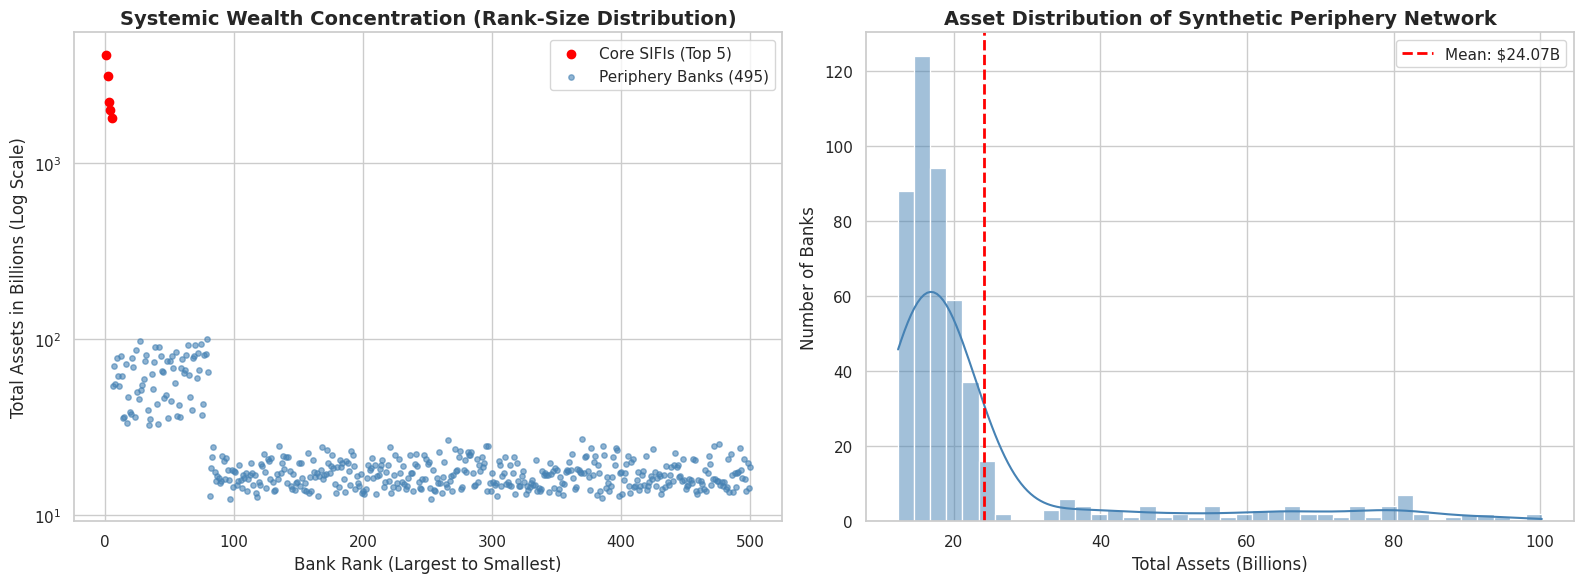

In [ ]:
# Extract the data
sifi_assets = [bank.total_assets() for node_id, bank in banks.items() if node_id < 5]
periphery_assets = [bank.total_assets() for node_id, bank in banks.items() if node_id >= 5]
all_assets = sorted(sifi_assets + periphery_assets, reverse=True)

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ranks = np.arange(1, 501)

# Wealth Distribution for Entire System
ax1.scatter(ranks[:5], sifi_assets, color='red', label='Core SIFIs (Top 5)', zorder=5)
ax1.scatter(ranks[5:], periphery_assets, color='steelblue', alpha=0.6, label='Periphery Banks (495)', s=15)
ax1.set_yscale('log')
ax1.set_title('Systemic Wealth Concentration (Rank-Size Distribution)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Bank Rank (Largest to Smallest)', fontsize=12)
ax1.set_ylabel('Total Assets in Billions (Log Scale)', fontsize=12)
ax1.legend()

# Periphery Histogram
sns.histplot(periphery_assets, bins=40, kde=True, color='steelblue', ax=ax2)
ax2.set_title('Asset Distribution of Synthetic Periphery Network', fontsize=14, fontweight='bold')
ax2.set_xlabel('Total Assets (Billions)', fontsize=12)
ax2.set_ylabel('Number of Banks', fontsize=12)
ax2.axvline(np.mean(periphery_assets), color='red', linestyle='dashed', linewidth=2, label=f'Mean: ${np.mean(periphery_assets):.2f}B')
ax2.legend()

plt.tight_layout()
plt.show()

## 10. Interbank Loan Distribution

To generate realistic systemic risk, the interbank exposure matrix must avoid arbitrary thresholds. We model the interbank lending capacity of the periphery using a continuous **Beta distribution**.

Regional banks lend between 0% and 6% of their total assets into the overnight interbank market. The exact dollar volume is continuously proportional to the bank's size, and the exposures are mapped directly onto the directed edges of the Stochastic Block Model generated earlier. This creates a realistic, heavily right-skewed topology where periphery banks are heavily exposed to the core hubs.

In [ ]:
target_interbank_assets        = np.zeros(500)
target_interbank_assets[0:5]   = [292.2, 325.2, 356.2, 134.8, 390.0]

for i in range(5, 500):
    base = sum(banks[i].assets.values())

    # Beta Distribution For Total Interbank Loans
    # 6% of assets in interbank loans
    exposure_pct = np.random.beta(1.5, 5.0) * 0.06

    # Interbank assets
    target_interbank_assets[i] = base * exposure_pct

for u in sim_G.nodes():
    successors = list(sim_G.successors(u))
    if not successors:
        continue
    total_borrower_size = sum(sum(banks[v].assets.values()) for v in successors)
    if total_borrower_size == 0:
        continue
    for v in successors:
        proportion           = sum(banks[v].assets.values()) / total_borrower_size
        sim_G[u][v]["weight"] = target_interbank_assets[u] * proportion

for i in range(500):
    banks[i].interbank_assets      = sum(
        sim_G[i][v]["weight"] for v in sim_G.successors(i)
    )
    banks[i].interbank_liabilities = sum(
        sim_G[u][i]["weight"] for u in sim_G.predecessors(i)
    )

# Set final liabilities
for i in range(500):
    banks[i].setup_initial_liabilities()

print("Network edges and initial liabilities set.\n")

Network edges and initial liabilities set.



## 11. Network Topology Visualization

Before executing the stress tests, we visualize the initialized interbank network. To maintain visual clarity across 500 nodes and thousands of edges, the rendering logic follows these specific steps:

*   **Dynamic Node Scaling:** Node sizes are proportional to the bank's total assets (`total_assets * 0.5`), visually representing the market share and 'gravitational pull' of different institutions.
*   **Identity Color-Coding:** We use a categorical color scheme where the **5 Core SIFIs are colored Red** (`#DC143C`) and the **495 Regional Periphery banks are colored Blue** (`#4682B4`).
*   **Exposure Filtering:** To avoid a 'hairball' effect, the visualization only draws heavy interbank credit lines—specifically those where the exposure exceeds **$100 Million**.
*   **Edge Weighting:** The thickness of the arrows is scaled by the actual dollar value of the lending relationship, allowing for an intuitive understanding of the network's risk concentration.
*   **Optimized Layout:** We utilize a Spring Layout with an adjusted optimal distance (`k=0.15`) and 100 iterations to maximize the separation between nodes while preserving the Core-Periphery structure.

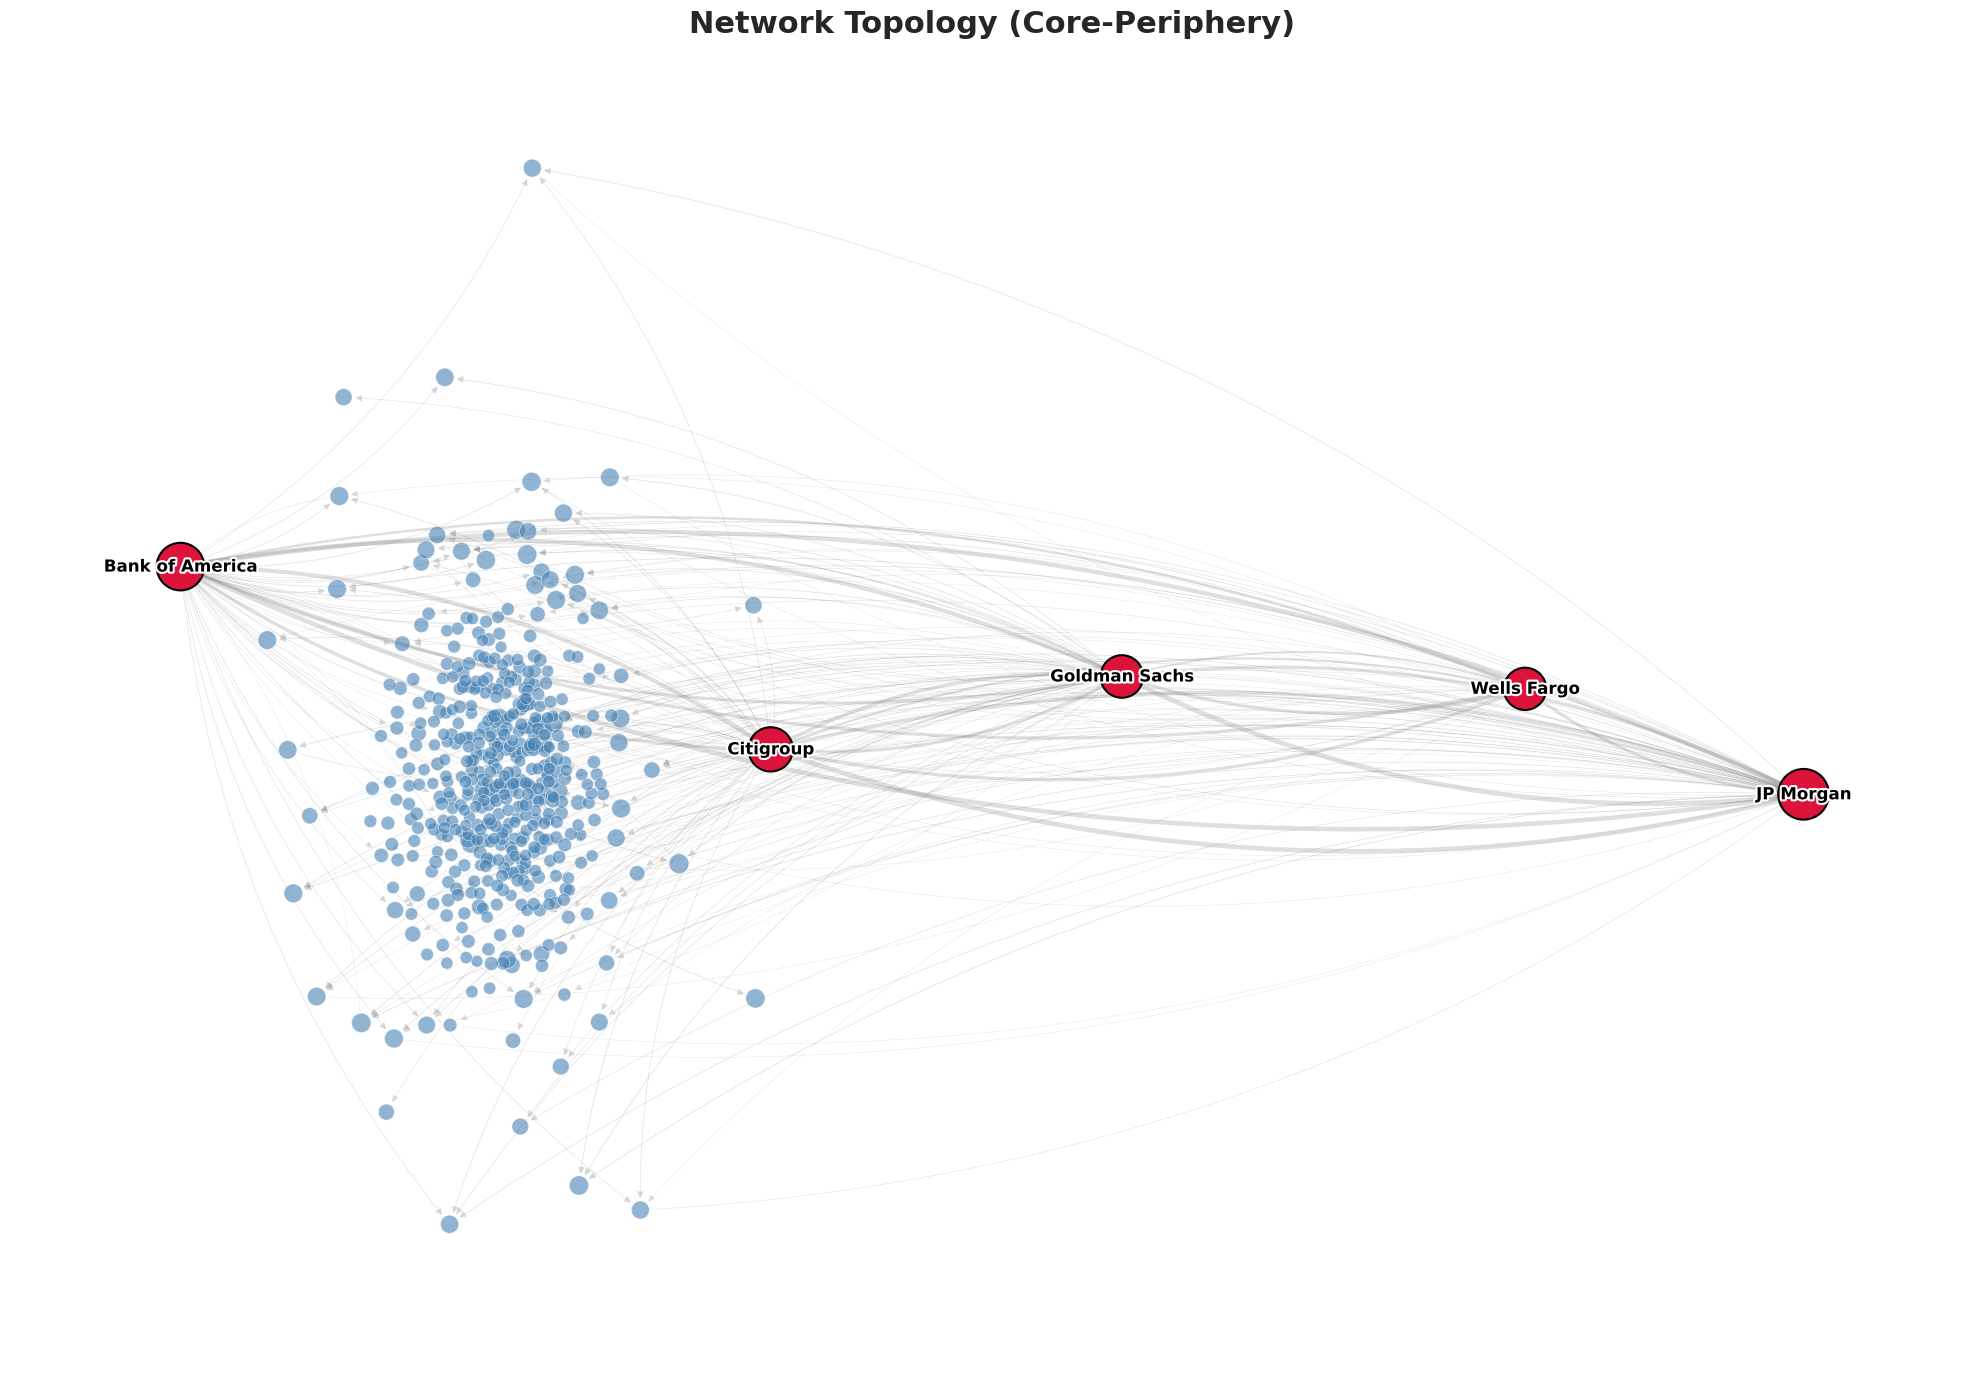

In [ ]:
plt.figure(figsize=(20, 14))

# Square Root Size Scaling
node_sizes = [max(30, np.sqrt(banks[i].total_assets()) * 20) for i in range(500)]

# Split nodes for Z-ordering
core_nodes = [i for i in range(5)]
periphery_nodes = [i for i in range(5, 500)]

pos = nx.kamada_kawai_layout(sim_G, scale=2.0)

# Regional Banks
nx.draw_networkx_nodes(
    sim_G, pos,
    nodelist=periphery_nodes,
    node_size=[node_sizes[i] for i in periphery_nodes],
    node_color='#4682B4',
    alpha=0.6,
    edgecolors='white',
    linewidths=0.5
)

# SIFIs
nx.draw_networkx_nodes(
    sim_G, pos,
    nodelist=core_nodes,
    node_size=[node_sizes[i] for i in core_nodes],
    node_color='#DC143C',
    edgecolors='black',
    linewidths=1.5
)

# Edge Formatting
threshold = 0.5
heavy_edges = [(u, v) for u, v, d in sim_G.edges(data=True) if d['weight'] > threshold]
edge_weights = [np.sqrt(sim_G[u][v]['weight']) * 0.35 for u, v in heavy_edges]

nx.draw_networkx_edges(
    sim_G, pos,
    edgelist=heavy_edges,
    width=edge_weights,
    edge_color='gray',
    alpha=0.25,
    arrows=True,
    arrowsize=10,
    arrowstyle='-|>',
    connectionstyle='arc3,rad=0.15'
)

# Labeling
labels = {i: banks[i].name for i in range(5)}
texts = nx.draw_networkx_labels(
    sim_G, pos, labels,
    font_size=12,
    font_weight='bold',
    font_color='black'
)

# White Bordering The Labels
for _, t in texts.items():
    t.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='white')])

plt.title("Network Topology (Core-Periphery)", fontsize=22, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 12. The Visualization Suite

To interpret the massive matrix of outputs generated by the ABM orchestrator, we define a comprehensive plotting suite (`plot_all`).

Rather than relying on basic line charts, this dashboard utilizes `matplotlib.gridspec` to render the macroeconomic impacts across six distinct, publication-ready analytical dimensions:
1. **Asset Deflation & Stabilisation:** Tracking the AI Price Index against 6- and 12-month SMAs, the TARP trigger, and the Vulture Capital floor.
2. **State Transitions (Contagion):** Visualizing the network flow of agents moving from Safe to Distressed to Defaulted.
3. **Liquidity vs. Bailouts:** Charting the velocity of FLARE deposit runs against the deployment of the TARP budget.
4. **Fire-Sale Microstructure:** Measuring gross bank selling against Vulture Capital absorption to find the net clearing volume.
5. **Phase-Space Portraits:** Mapping the system trajectory in (Price, Default) space to evaluate the severity of the regime shift.
6. **Government Efficiency:** Evaluating the cumulative taxpayer cost per saved bank, and the breakdown of orderly mergers versus outright defaults.

In [ ]:
# Semantics
C = {
    "bg"          : "#FAFAF7",
    "panel_bg"    : "#F4F3EE",
    "grid"        : "#DEDAD2",
    "text_primary": "#1A1A1A",
    "text_muted"  : "#6B6559",
    "accent_red"  : "#B22222",
    "accent_gold" : "#CC8A00",
    "accent_blue" : "#1B3A6B",
    "accent_green": "#1D6B3A",
    "accent_purple": "#6B2D8B",
    "accent_steel": "#445566",
    "sifi_red"    : "#8B0000",
    "light_blue"  : "#C8D8EC",
    "light_gold"  : "#FFE5A0",
    "light_red"   : "#F0BBBB",
    "vulture"     : "#2E8B57",
}

FONT_TITLE   = {"family": "serif", "size": 13, "weight": "bold",  "color": C["text_primary"]}
FONT_AXIS    = {"family": "serif", "size": 10, "weight": "normal", "color": C["text_primary"]}
FONT_ANNOT   = {"family": "serif", "size":  8, "weight": "normal", "color": C["text_muted"]}
FONT_SUPTITLE= {"family": "serif", "size": 15, "weight": "bold",  "color": C["text_primary"]}

plt.rcParams.update({
    "font.family"        : "serif",
    "axes.facecolor"     : C["panel_bg"],
    "figure.facecolor"   : C["bg"],
    "axes.edgecolor"     : C["grid"],
    "axes.labelcolor"    : C["text_primary"],
    "xtick.color"        : C["text_muted"],
    "ytick.color"        : C["text_muted"],
    "grid.color"         : C["grid"],
    "grid.linestyle"     : ":",
    "grid.linewidth"     : 0.8,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "legend.framealpha"  : 0.92,
    "legend.edgecolor"   : C["grid"],
    "legend.fancybox"    : False,
    "legend.fontsize"    : 8,
})

# ── Helper utilities ──────────────────────────────────────────────────

def year_xticks(ax, max_tick=120, step=12):
    positions = np.arange(0, max_tick + 1, step)
    ax.set_xticks(positions)
    ax.set_xticklabels([f"Yr {int(p/12)}" for p in positions], **FONT_ANNOT)

def shade_regimes(ax, ticks, regimes, ymin=0, ymax=1):
    in_contagion = False
    start = None
    for i, (t, r) in enumerate(zip(ticks, regimes)):
        if r == "Distressed" and not in_contagion:
            start = t
            in_contagion = True
        elif r != "Distressed" and in_contagion:
            ax.axvspan(start, t, ymin=ymin, ymax=ymax,
                       color=C["accent_red"], alpha=0.06, zorder=0)
            in_contagion = False
    if in_contagion and start is not None:
        ax.axvspan(start, ticks[-1], ymin=ymin, ymax=ymax,
                   color=C["accent_red"], alpha=0.06, zorder=0)

def annotate_sifi_events(ax, ticks, sifi_defaults, y_frac=0.92):
    prev = 0
    events = []
    for t, s in zip(ticks, sifi_defaults):
        if s > prev:
            ax.axvline(x=t, color=C["sifi_red"], linestyle="--",
                       linewidth=1.2, alpha=0.7, zorder=3)
            ax.text(t + 1.2, ax.get_ylim()[0] +
                    (ax.get_ylim()[1] - ax.get_ylim()[0]) * y_frac,
                    f"SIFI−{s}", color=C["sifi_red"],
                    fontsize=7, fontstyle="italic", va="top")
            events.append(t)
            prev = s
    return events

def rolling(series, w=6):
    return pd.Series(series).rolling(w, min_periods=1).mean().values

def diff_series(series):
    s = np.array(series, dtype=float)
    return np.concatenate([[0], np.diff(s)])


# Final Simulation Plotting
def plot_all(simulation_results: dict,
             n_banks: int = 500,
             n_core: int = 5,
             vulture_threshold: float = 0.70,
             vulture_reserves: float = 5000.0,
             max_budget: float = 10000.0,
             save_prefix: str = None):

    df = pd.DataFrame(simulation_results)
    ticks    = df["tick"].values
    T        = len(ticks)

    ai_price  = df["ai_price_index"].values
    defaults  = df["defaults"].values
    sifi_def  = df["sifi_defaults"].values
    distressed= df["distressed_banks"].values
    tarp_cum  = df["taxpayer_cost_cumulative"].values
    dep_flight= df["deposit_flight"].values
    net_assets= df["total_network_assets"].values
    regimes   = df["market_regime"].values
    fire_vol  = df["fire_sale_volume"].values
    merged    = df["merged_count"].values

    safe_banks   = n_banks - defaults - distressed
    tarp_flow    = diff_series(tarp_cum)

    df["merged_flow"] = diff_series(merged)
    df["default_flow"] = diff_series(defaults)

    distress_flow= np.diff(np.concatenate([[0], distressed]))
    initial_assets = net_assets[0] if net_assets[0] > 0 else 1.0
    assets_lost_cum= initial_assets - net_assets
    assets_loss_rate = diff_series(assets_lost_cum)

    # ── FIG 1: Main Dashboard
    fig1, axes = plt.subplots(3, 1, figsize=(15, 17), gridspec_kw={"hspace": 0.38})
    fig1.suptitle("ABM Systemic Risk Simulation — Executive Dashboard", **FONT_SUPTITLE, y=0.98)

    ax = axes[0]
    shade_regimes(ax, ticks, regimes, ymin=0, ymax=1)
    ax.plot(ticks, ai_price, color=C["accent_red"], lw=1.0, alpha=0.35, label="Raw AI Price Index")
    sma6  = rolling(ai_price, 6)
    sma12 = rolling(ai_price, 12)
    ax.plot(ticks, sma6,  color=C["accent_gold"], lw=2.2, label="6-Month SMA")
    ax.plot(ticks, sma12, color=C["accent_red"],  lw=2.5, linestyle="-", label="12-Month SMA")
    ax.fill_between(ticks, ai_price, sma6, where=(ai_price < sma6), color=C["accent_red"], alpha=0.12, label="Below-SMA excess stress")
    ax.axhline(y=vulture_threshold, color=C["vulture"], linestyle="--", lw=2.0, label=f"Vulture Capital Floor ({vulture_threshold:.0%})")
    ax.axhline(y=0.85, color=C["accent_gold"], linestyle=":", lw=1.4, alpha=0.8, label="TARP Trigger (85¢)")
    ax.axhline(y=1.0, color=C["accent_steel"], linestyle="-", lw=0.8, alpha=0.4)
    annotate_sifi_events(ax, ticks, sifi_def, y_frac=0.15)
    ax.set_ylabel("Asset Price Index  (1.0 = Par)", **FONT_AXIS)
    ax.set_title("Panel A  ·  Asset Deflation & Stabilisation Thresholds", **FONT_TITLE)
    ax.set_ylim(max(0.05, min(ai_price) - 0.05), 1.08)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(loc="lower left", ncol=2)
    ax.grid(True)

    ax = axes[1]
    shade_regimes(ax, ticks, regimes, ymin=0, ymax=1)
    ax.stackplot(ticks, safe_banks, distressed, defaults,
                 labels=["Safe Banks", "Distressed Banks", "Defaulted Banks"],
                 colors=[C["light_blue"], C["light_gold"], C["light_red"]],
                 alpha=0.85, edgecolors=[C["accent_blue"], C["accent_gold"], C["accent_red"]], linewidth=0.4)
    ax.plot(ticks, merged, color=C["accent_purple"], lw=1.8, linestyle="-.", label="Cumulative Forced Mergers", zorder=5)
    sifi_events = annotate_sifi_events(ax, ticks, sifi_def, y_frac=0.78)
    if sifi_events:
        ax.text(sifi_events[0] + 2, 310, "First Core SIFI\nCollapse", color=C["sifi_red"], fontsize=8, fontweight="bold", va="top")
    ax.set_ylabel("Number of Bank Agents", **FONT_AXIS)
    ax.set_title("Panel B  ·  Systemic Contagion — State Transition of All Agents", **FONT_TITLE)
    ax.set_ylim(0, n_banks * 1.05)
    ax.legend(loc="center right", ncol=1)
    ax.grid(True)

    ax = axes[2]
    shade_regimes(ax, ticks, regimes, ymin=0, ymax=1)
    ax.plot(ticks, tarp_cum, color=C["accent_green"], lw=2.8, label="Cumulative TARP Spending ($B)")
    ax.fill_between(ticks, tarp_cum, color=C["accent_green"], alpha=0.12)
    ax.set_ylabel("Cumulative TARP Spend ($B)", **{**FONT_AXIS, "color": C["accent_green"]})
    ax.tick_params(axis="y", labelcolor=C["accent_green"])
    ax_r = ax.twinx()
    ax_r.bar(ticks, dep_flight, color=C["accent_purple"], alpha=0.45, width=1.0, label="Monthly FLARE Withdrawals ($B)")
    ax_r.set_ylabel("FLARE Deposit Withdrawals ($B)", **{**FONT_AXIS, "color": C["accent_purple"]})
    ax_r.tick_params(axis="y", labelcolor=C["accent_purple"])
    lines1, lab1 = ax.get_legend_handles_labels()
    lines2, lab2 = ax_r.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lab1 + lab2, loc="upper left")
    ax.set_xlabel("Simulation Time", **FONT_AXIS)
    ax.set_title("Panel C  ·  Liquidity Crisis: Bank Runs vs. Government Response", **FONT_TITLE)
    ax.grid(True)

    for ax in axes:
        year_xticks(ax, max_tick=T)

    fig2 = plt.figure(figsize=(15, 13))
    fig2.suptitle("Fire-Sale Mechanics — Gross Sell Volume, Vulture Absorption & Net Price Impact", **FONT_SUPTITLE, y=0.98)
    gs2 = gridspec.GridSpec(3, 2, figure=fig2, hspace=0.45, wspace=0.35)
    ax2a = fig2.add_subplot(gs2[0, :])
    ax2b = fig2.add_subplot(gs2[1, 0])
    ax2c = fig2.add_subplot(gs2[1, 1])
    ax2d = fig2.add_subplot(gs2[2, :])

    vulture_buy_est = np.where(
        ai_price < vulture_threshold,
        vulture_reserves * (vulture_threshold - ai_price) ** 2,
        0.0
    )
    net_vol_est = np.maximum(fire_vol - vulture_buy_est, 0)
    vulture_absorbed = np.minimum(vulture_buy_est, fire_vol)

    ax2a.bar(ticks, fire_vol, color=C["accent_red"], alpha=0.55, width=1.0, label="Gross Bank Sell Volume ($B face value)")
    ax2a.bar(ticks, -vulture_absorbed, color=C["vulture"], alpha=0.60, width=1.0, label="Vulture Capital Absorption ($B, below axis)")
    ax2a.bar(ticks, net_vol_est, color=C["accent_gold"], alpha=0.70, width=1.0, label="Net Volume (Sell − Vulture Buy, $B)")
    ax2a.axhline(y=0, color=C["accent_steel"], lw=0.9)
    ax2a.set_ylabel("Volume ($B)", **FONT_AXIS)
    ax2a.set_title("2A  ·  Gross Fire-Sale Volume vs. Vulture Capital Absorption", **FONT_TITLE)
    ax2a.legend(ncol=3)
    ax2a.grid(True)
    year_xticks(ax2a, T)

    price_change = diff_series(ai_price)
    bar_colors = [C["accent_green"] if v >= 0 else C["accent_red"] for v in price_change]
    ax2b.bar(ticks, price_change * 100, color=bar_colors, alpha=0.75, width=1.0)
    ax2b.axhline(y=0, color=C["accent_steel"], lw=1.0)
    ax2b.set_ylabel("Monthly Price Change (%)", **FONT_AXIS)
    ax2b.set_title("2B  ·  Monthly Price Δ\n(green=recovery, red=decline)", **FONT_TITLE)
    ax2b.grid(True)
    year_xticks(ax2b, T)

    cum_vol = np.cumsum(fire_vol)
    ax2c.fill_between(ticks, cum_vol, color=C["accent_red"], alpha=0.18)
    ax2c.plot(ticks, cum_vol, color=C["accent_red"], lw=2.2, label="Cumulative Gross Sell Volume")
    cum_net = np.cumsum(net_vol_est)
    ax2c.plot(ticks, cum_net, color=C["accent_gold"], lw=2.0, linestyle="--", label="Cumulative Net Volume (post-vulture)")
    ax2c.set_ylabel("Cumulative Volume ($B)", **FONT_AXIS)
    ax2c.set_title("2C  ·  Cumulative\nFire-Sale Volume", **FONT_TITLE)
    ax2c.legend()
    ax2c.grid(True)
    year_xticks(ax2c, T)

    distress_new = np.maximum(distress_flow, 0)
    distress_recover = np.minimum(distress_flow, 0)
    ax2d.bar(ticks,  distress_new, color=C["accent_gold"], alpha=0.7, width=1.0, label="New Distress Events / month")
    ax2d.bar(ticks, -distress_recover, color=C["accent_green"], alpha=0.6, width=1.0, label="Distress Resolved / month (recovery)")
    ax2d.plot(ticks, rolling(distressed, 3), color=C["accent_red"], lw=2.2, label="3-Month Rolling Avg Distressed Count")
    ax2d.set_ylabel("Banks", **FONT_AXIS)
    ax2d.set_xlabel("Simulation Time", **FONT_AXIS)
    ax2d.set_title("2D  ·  Distressed Bank Flow — Stochastic Hesitation Creates Lagged, Wave-Structured Selling", **FONT_TITLE)
    ax2d.legend(ncol=3)
    ax2d.grid(True)
    year_xticks(ax2d, T)

    # ── FIG 3: Solvency Erosion Dashboard
    fig3, axes3 = plt.subplots(2, 2, figsize=(15, 12), gridspec_kw={"hspace": 0.42, "wspace": 0.35})
    fig3.suptitle("Network Solvency Erosion — Asset Destruction & Capital Adequacy", **FONT_SUPTITLE, y=0.98)

    ax = axes3[0, 0]
    shade_regimes(ax, ticks, regimes)
    ax.fill_between(ticks, net_assets, color=C["accent_blue"], alpha=0.15)
    ax.plot(ticks, net_assets, color=C["accent_blue"], lw=2.3, label="Total Active Network Assets ($B)")
    ax.plot(ticks, rolling(net_assets, 6), color=C["accent_gold"], lw=1.8, linestyle="--", label="6-Month SMA")
    ax.axhline(y=initial_assets, color=C["accent_steel"], lw=0.9, linestyle=":", alpha=0.7, label="Initial Endowment")
    annotate_sifi_events(ax, ticks, sifi_def)
    ax.set_ylabel("Network Assets ($B)", **FONT_AXIS)
    ax.set_title("3A  ·  Total Network Asset Base", **FONT_TITLE)
    ax.legend(fontsize=7)
    ax.grid(True)
    year_xticks(ax, T)

    ax = axes3[0, 1]
    shade_regimes(ax, ticks, regimes)
    pct_lost = (assets_lost_cum / initial_assets) * 100
    ax.fill_between(ticks, pct_lost, color=C["accent_red"], alpha=0.20)
    ax.plot(ticks, pct_lost, color=C["accent_red"], lw=2.3, label="% of Initial Assets Destroyed")
    ax.set_ylabel("Cumulative Asset Destruction (%)", **FONT_AXIS)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=1))
    ax.set_title("3B  ·  Cumulative Asset Destruction\nas % of Initial Endowment", **FONT_TITLE)
    ax.legend()
    ax.grid(True)
    year_xticks(ax, T)

    ax = axes3[1, 0]
    shade_regimes(ax, ticks, regimes)
    ax.bar(ticks, assets_loss_rate, color=C["accent_red"], alpha=0.55, width=1.0, label="Monthly Asset Loss ($B)")
    ax.plot(ticks, rolling(assets_loss_rate, 6), color=C["sifi_red"], lw=2.0, label="6-Month SMA Loss Rate")
    ax.set_ylabel("Asset Destruction Rate ($B/month)", **FONT_AXIS)
    ax.set_xlabel("Simulation Time", **FONT_AXIS)
    ax.set_title("3C  ·  Monthly Asset Loss Rate\n(Shock Velocity)", **FONT_TITLE)
    ax.legend()
    ax.grid(True)
    year_xticks(ax, T)

    ax = axes3[1, 1]
    shade_regimes(ax, ticks, regimes)
    with np.errstate(divide='ignore', invalid='ignore'):
        fragility = np.where(assets_lost_cum > 1.0, defaults / (assets_lost_cum / 100.0), 0.0)
    ax.fill_between(ticks, fragility, color=C["accent_purple"], alpha=0.18)
    ax.plot(ticks, fragility, color=C["accent_purple"], lw=2.2, label="Default Intensity\n(bank failures / $100B loss)")
    ax.plot(ticks, rolling(fragility, 6), color=C["accent_steel"], lw=1.5, linestyle="--", alpha=0.8, label="6M SMA")
    ax.set_ylabel("Default Intensity (banks / $100B loss)", **FONT_AXIS)
    ax.set_xlabel("Simulation Time", **FONT_AXIS)
    ax.set_title("3D  ·  System Fragility Index\n(Default Sensitivity to Asset Erosion)", **FONT_TITLE)
    ax.legend(fontsize=7)
    ax.grid(True)
    year_xticks(ax, T)

    # FIG 4: Cascade Transition Matrix
    fig4, axes4 = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"wspace": 0.40})
    fig4.suptitle("Contagion Cascade — State Transition Velocity & Survival Analysis", **FONT_SUPTITLE, y=1.01)

    ax = axes4[0]
    shade_regimes(ax, ticks, regimes)
    new_defaults_per_tick  = np.maximum(df["default_flow"].values, 0)
    new_distress_per_tick  = np.maximum(distress_flow, 0)
    recoveries_per_tick    = np.maximum(-distress_flow, 0)
    ax.bar(ticks, new_defaults_per_tick,  color=C["accent_red"],    alpha=0.75, width=1.0, label="New Defaults / tick")
    ax.bar(ticks, new_distress_per_tick,  color=C["accent_gold"],   alpha=0.60, width=1.0, label="New Distress Events / tick", bottom=new_defaults_per_tick)
    ax.bar(ticks, recoveries_per_tick,    color=C["accent_green"],  alpha=0.60, width=1.0, label="Recoveries (Distress→Safe) / tick", bottom=-(recoveries_per_tick))
    ax.axhline(y=0, color=C["accent_steel"], lw=1.0)
    ax.set_ylabel("Bank State Transitions per Month", **FONT_AXIS)
    ax.set_xlabel("Simulation Time", **FONT_AXIS)
    ax.set_title("4A  ·  Monthly State-Transition Velocity\n(Upward = deterioration, Downward = recovery)", **FONT_TITLE)
    ax.legend()
    ax.grid(True)
    year_xticks(ax, T)

    ax = axes4[1]
    shade_regimes(ax, ticks, regimes)
    pct_safe       = safe_banks / n_banks * 100
    pct_distressed = distressed  / n_banks * 100
    pct_defaulted  = defaults    / n_banks * 100
    ax.plot(ticks, pct_safe, color=C["accent_blue"], lw=2.5, label=f"Safe  ({pct_safe[-1]:.1f}% at end)")
    ax.plot(ticks, pct_distressed, color=C["accent_gold"], lw=2.0, linestyle="--", label=f"Distressed  (peak {distressed.max()} banks)")
    ax.plot(ticks, pct_defaulted, color=C["accent_red"], lw=2.0, linestyle="-.", label=f"Defaulted  ({pct_defaulted[-1]:.1f}% at end)")
    ax.set_ylabel("Share of Total Network (%)", **FONT_AXIS)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.set_xlabel("Simulation Time", **FONT_AXIS)
    ax.set_title("4B  ·  Network Survival Curve\n(Fraction of 500 Agents in Each State)", **FONT_TITLE)
    ax.set_ylim(0, 105)
    ax.legend()
    ax.grid(True)
    year_xticks(ax, T)

    # FIG 5: Regime Portrait
    fig5, axes5 = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"wspace": 0.40})
    fig5.suptitle("Phase-Space Portraits — System Trajectory in (Price, Default) Space", **FONT_SUPTITLE, y=1.01)

    ax = axes5[0]
    regime_colors = {
        "Stable"    : C["accent_blue"],
        "Distressed": C["accent_red"],
    }
    for regime, col in regime_colors.items():
        mask = np.array(regimes) == regime
        if mask.sum() == 0:
            continue
        ax.scatter(defaults[mask], ai_price[mask], c=col, s=distressed[mask] * 0.8 + 8, alpha=0.55, label=regime, edgecolors="none", zorder=3)

    points = np.array([defaults, ai_price]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, linewidths=0.6, alpha=0.25, color=C["accent_steel"])
    ax.add_collection(lc)
    ax.scatter(defaults[0],  ai_price[0],  marker="o", s=80, zorder=5, color=C["accent_green"], edgecolors="white", lw=1.5, label="Start")
    ax.scatter(defaults[-1], ai_price[-1], marker="X", s=100, zorder=5, color=C["sifi_red"], edgecolors="white", lw=1.5, label="End")
    ax.axhline(y=vulture_threshold, color=C["vulture"], linestyle="--", lw=1.5, alpha=0.8, label=f"Vulture Floor ({vulture_threshold:.0%})")
    ax.set_xlabel("Cumulative Defaults (# banks)", **FONT_AXIS)
    ax.set_ylabel("AI Price Index", **FONT_AXIS)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_title("5A  ·  System Trajectory  (bubble size = # distressed banks)", **FONT_TITLE)
    ax.legend(fontsize=7)
    ax.grid(True)

    ax = axes5[1]
    sc2 = ax.scatter(dep_flight, ai_price, c=ticks, cmap="RdYlBu_r", s=40, alpha=0.55, edgecolors="none", zorder=3)
    cbar = fig5.colorbar(sc2, ax=ax, shrink=0.75, pad=0.03)
    cbar.set_label("Simulation Month", fontsize=8, color=C["text_muted"])
    cbar.ax.yaxis.set_tick_params(color=C["text_muted"])
    ax.axhline(y=vulture_threshold, color=C["vulture"], linestyle="--", lw=1.5, alpha=0.8)
    ax.set_xlabel("FLARE Monthly Deposit Flight ($B)", **FONT_AXIS)
    ax.set_ylabel("AI Price Index", **FONT_AXIS)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_title("5B  ·  FLARE Run Severity vs. Asset Price\n(colour = simulation month, earlier=blue, later=red)", **FONT_TITLE)
    ax.grid(True)

    # FIG 6: TARP Efficiency & Merger Waterfall
    fig6, axes6 = plt.subplots(2, 2, figsize=(15, 12), gridspec_kw={"hspace": 0.45, "wspace": 0.38})
    fig6.suptitle("Government Intervention Analysis — TARP Efficiency & Forced Merger Dynamics", **FONT_SUPTITLE, y=0.98)

    ax = axes6[0, 0]
    shade_regimes(ax, ticks, regimes)
    ax.bar(ticks, tarp_flow, color=C["accent_green"], alpha=0.70, width=1.0, label="TARP Spend per Month ($B)")
    ax.plot(ticks, rolling(tarp_flow, 6), color=C["sifi_red"], lw=2.0, label="6-Month SMA Spend Rate")
    ax.set_ylabel("Monthly TARP Disbursement ($B)", **FONT_AXIS)
    ax.set_title("6A  ·  TARP Monthly Disbursement\n(marginal government spend per tick)", **FONT_TITLE)
    ax.legend()
    ax.grid(True)
    year_xticks(ax, T)

    ax = axes6[0, 1]
    shade_regimes(ax, ticks, regimes)
    banks_saved_cumulative = merged.copy()
    with np.errstate(divide='ignore', invalid='ignore'):
        cost_per_bank = np.where(banks_saved_cumulative > 0, tarp_cum / banks_saved_cumulative, np.nan)
    ax.plot(ticks, cost_per_bank, color=C["accent_purple"], lw=2.2, label="TARP Cost per Merger-Saved Bank ($B)")
    ax.fill_between(ticks, cost_per_bank, where=~np.isnan(cost_per_bank), color=C["accent_purple"], alpha=0.12)
    ax.set_ylabel("Cost per Bank Saved ($B)", **FONT_AXIS)
    ax.set_title("6B  ·  Government Efficiency\nCumulative TARP / Cumulative Forced Mergers", **FONT_TITLE)
    ax.legend()
    ax.grid(True)
    year_xticks(ax, T)

    ax = axes6[1, 0]
    year_labels = [f"Yr {y+1}" for y in range(max(df["year"]))]
    mergers_by_year = df.groupby("year")["merged_flow"].sum().values
    defaults_by_year = df.groupby("year")["default_flow"].sum().values

    x_pos = np.arange(len(year_labels))
    ax.bar(x_pos - 0.2, mergers_by_year,  0.35, color=C["accent_green"], alpha=0.80, label="Forced Mergers")
    ax.bar(x_pos + 0.2, defaults_by_year, 0.35, color=C["accent_red"], alpha=0.75, label="Outright Defaults")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(year_labels, **FONT_ANNOT)
    ax.set_ylabel("Bank Failures (count)", **FONT_AXIS)
    ax.set_xlabel("Year", **FONT_AXIS)
    ax.set_title("6C  ·  Annual Failure Mode Breakdown\nMergers (orderly) vs. Outright Defaults (disorderly)", **FONT_TITLE)
    ax.legend()
    ax.grid(True, axis="y")

    ax = axes6[1, 1]
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, 3.5)
    final_tarp  = tarp_cum[-1]
    pct_used    = min(final_tarp / max_budget, 1.0)

    ax.barh([1], [pct_used], left=[0], height=0.5, color=C["accent_red"], alpha=0.80)
    ax.barh([1], [1 - pct_used], left=[pct_used], height=0.5, color=C["accent_green"], alpha=0.50)
    ax.text(pct_used / 2, 1, f"{pct_used:.1%}", ha="center", va="center", color="white", fontsize=12, fontweight="bold")
    ax.text(pct_used + (1 - pct_used) / 2, 1, f"{(1-pct_used):.1%}", ha="center", va="center", color=C["text_primary"], fontsize=11)
    ax.text(0.5, 2.2, f"Total TARP Deployed: ${final_tarp:,.1f}B\nof ${max_budget:,.0f}B Budget", ha="center", va="center", fontsize=11, color=C["text_primary"], fontfamily="serif")
    ax.text(0.5, 0.0, f"Forced Mergers: {int(merged[-1])}   |   Outright Defaults: {int(defaults[-1])}   |   SIFIs Failed: {int(sifi_def[-1])} / {n_core}", ha="center", va="center", fontsize=9, color=C["text_muted"], fontfamily="serif")
    ax.set_title("6D  ·  TARP Budget Utilisation\n& Final Outcome Summary", **FONT_TITLE)
    ax.axis("off")

    for ax in fig1.get_axes() + fig2.get_axes() + fig3.get_axes() + fig4.get_axes() + fig5.get_axes() + fig6.get_axes():
        for spine in ax.spines.values():
            spine.set_edgecolor(C["grid"])
        ax.tick_params(labelsize=8, colors=C["text_muted"])

    plt.show()



## 13. Testing & Execution



════════════════════════════════════════════════════════════════════
  ABM SYSTEMIC-RISK SIMULATION
  10 years × 12 ticks = 120 months
  TARP Budget : $1000.0B
  FLARE Tw    : 1.0  (1.0=2008-slow, 5.0=SVB-flash)
  Mkt Depth   : σ=0.2, κ=0.05, ADV=$1300.0B
  Vulture     : $2,700B reserves, activates below 85%
════════════════════════════════════════════════════════════════════


  YEAR 1 | Regime: STABLE

  ── Year 1 Annual Summary ──────────────────
     Status           :  Market Stable (No Active Distress)
     Total defaults   : 0 (0 SIFIs)
     Forced mergers   : 0
     Net assets       : $26860.45B
     Taxpayer cost    : $0.00B
     AI Price Index   : 1.0387
     Market Regime    : Stable

  YEAR 2 | Regime: STABLE
  [T015] FIRE-SALE: 2 distressed, $30.59B gross sold, 30 fixed-point iters. AI Index: 0.9849  
  [T016] FLARE: $0.62B funding withdrawn (Tw=1.0).
  [T016] FIRE-SALE: 9 distressed, $52.96B gross sold, 30 fixed-point iters. AI Index: 0.9818  
  [T017] FLARE: $1.32B fund

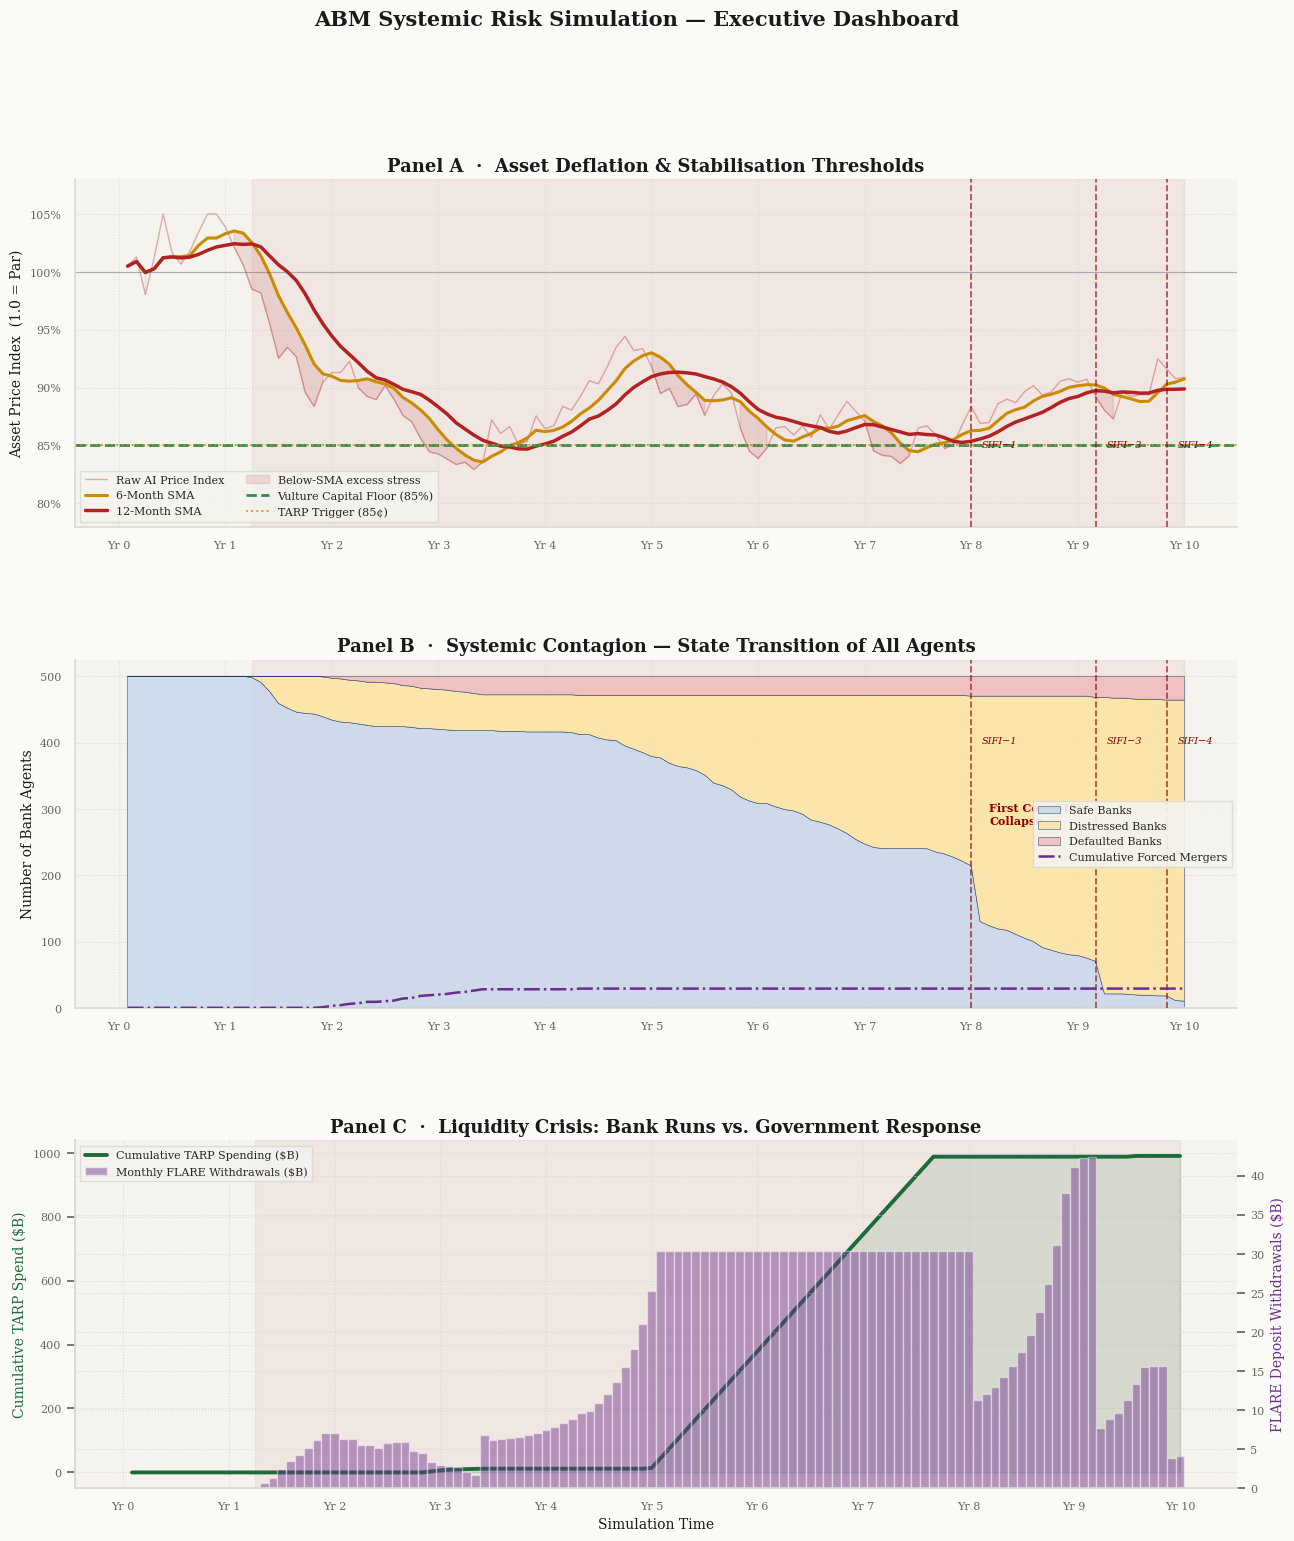

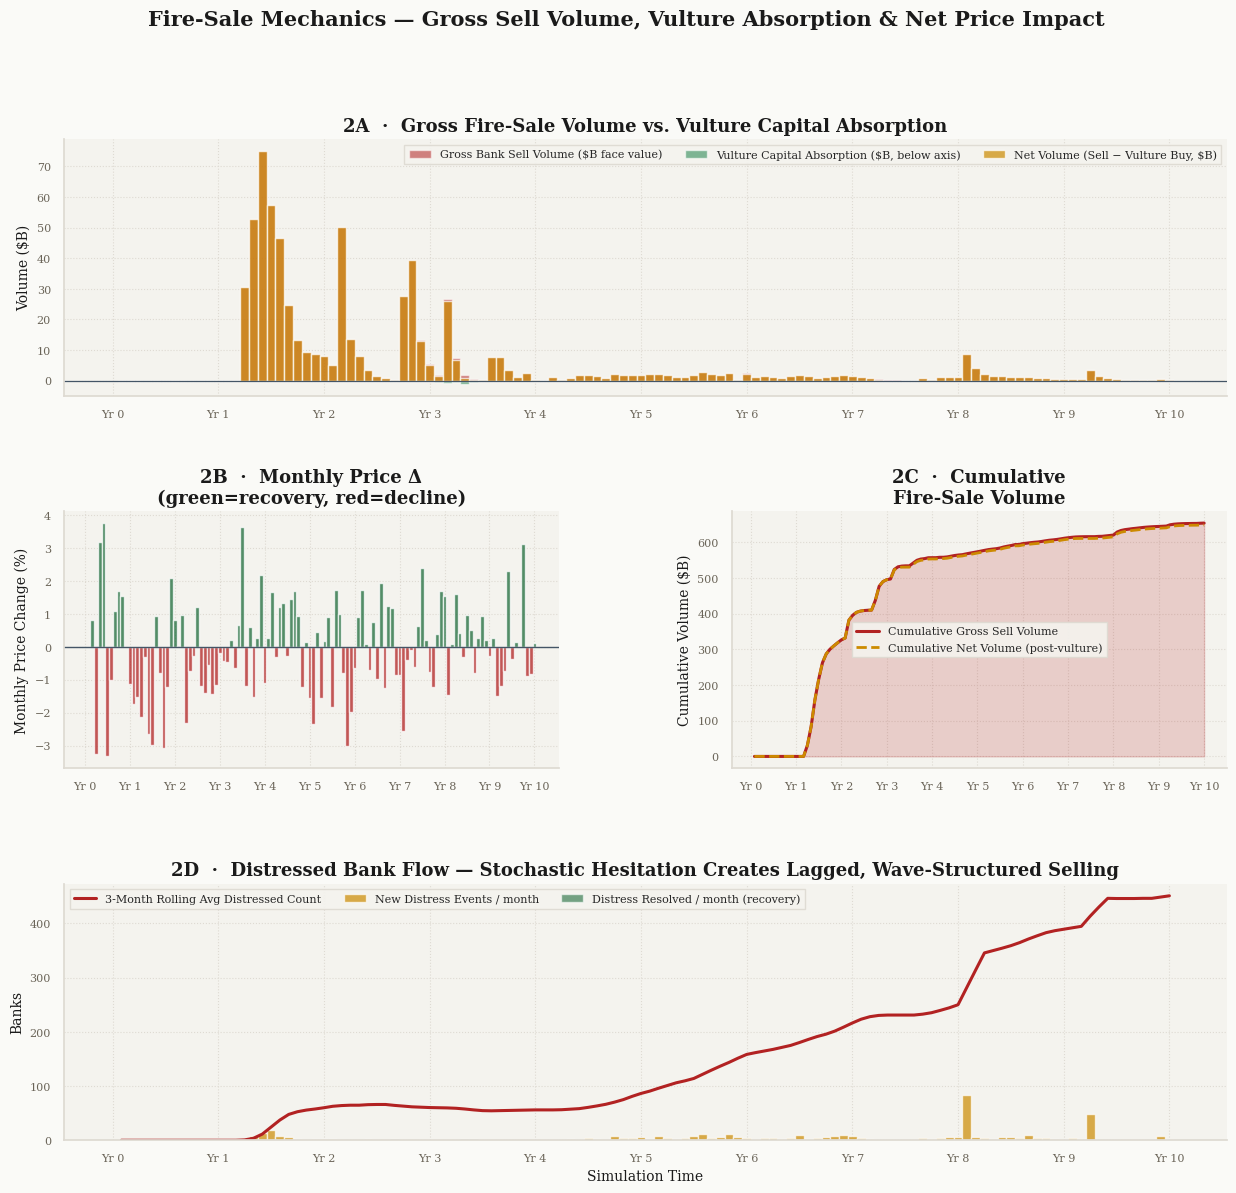

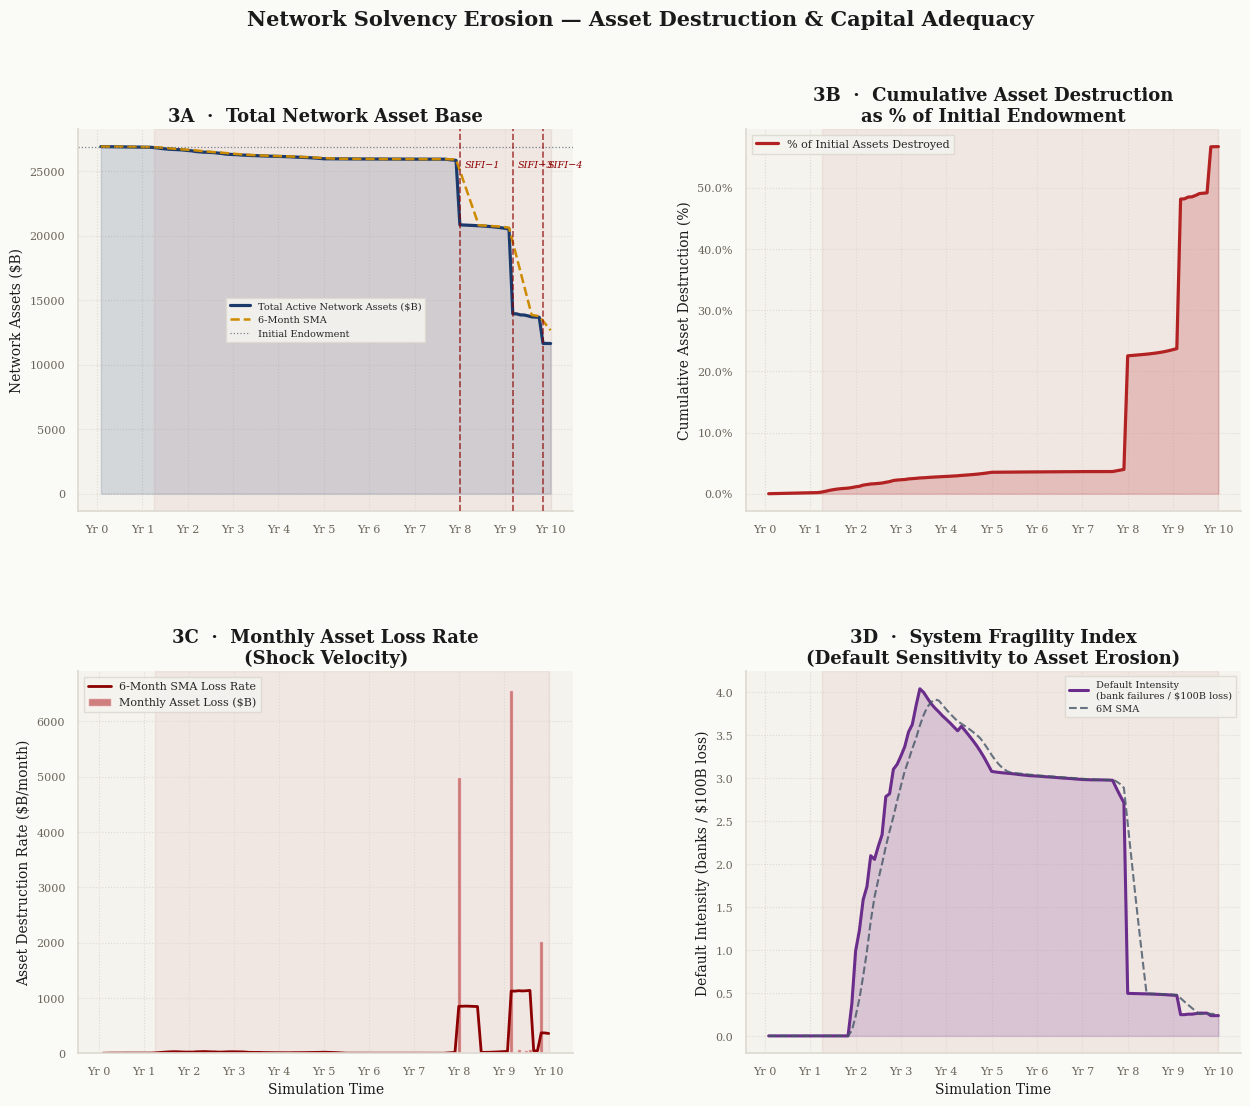

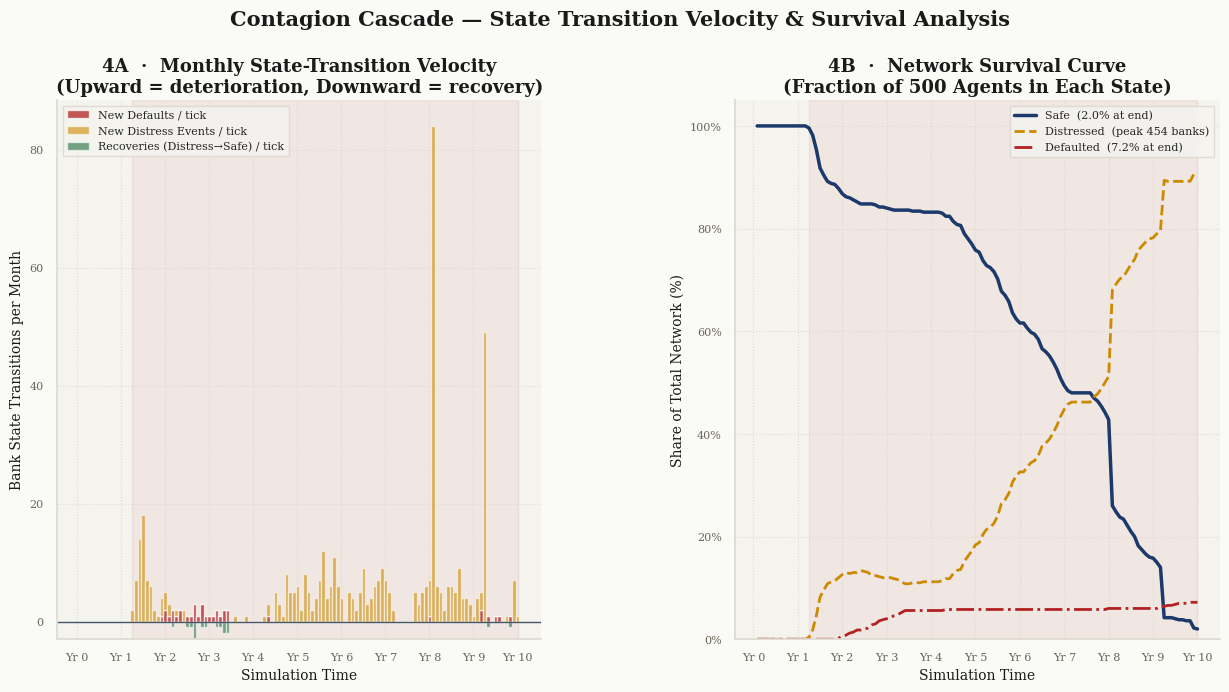

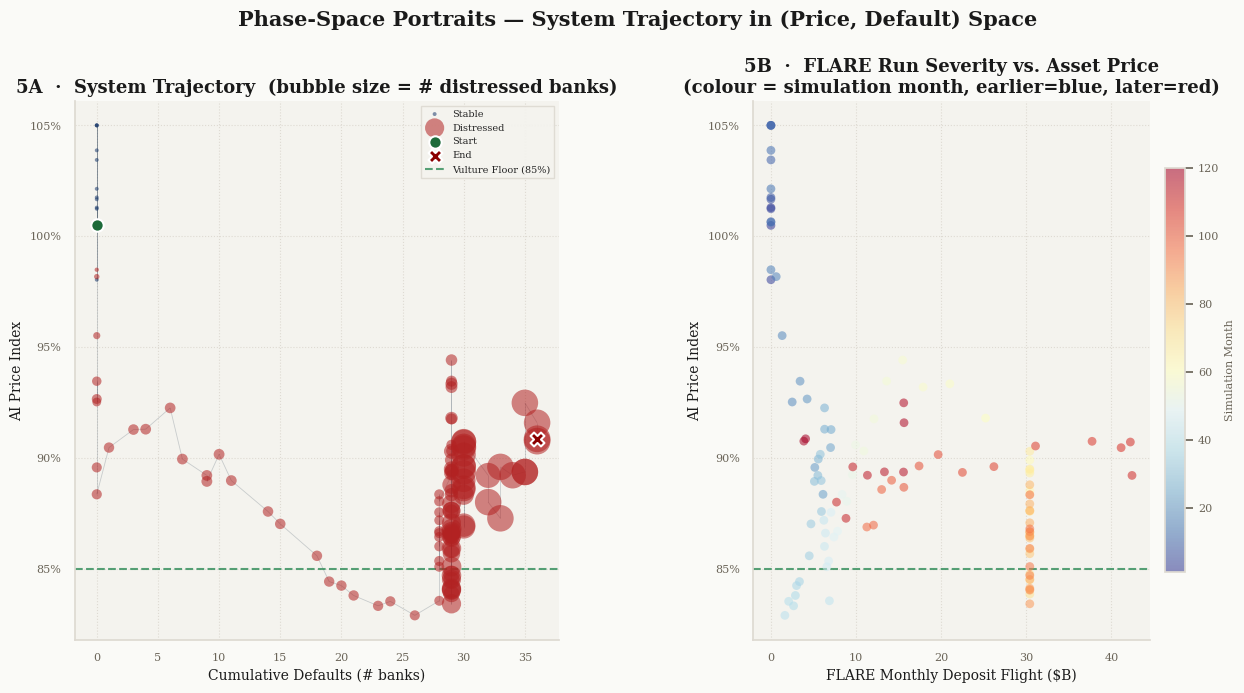

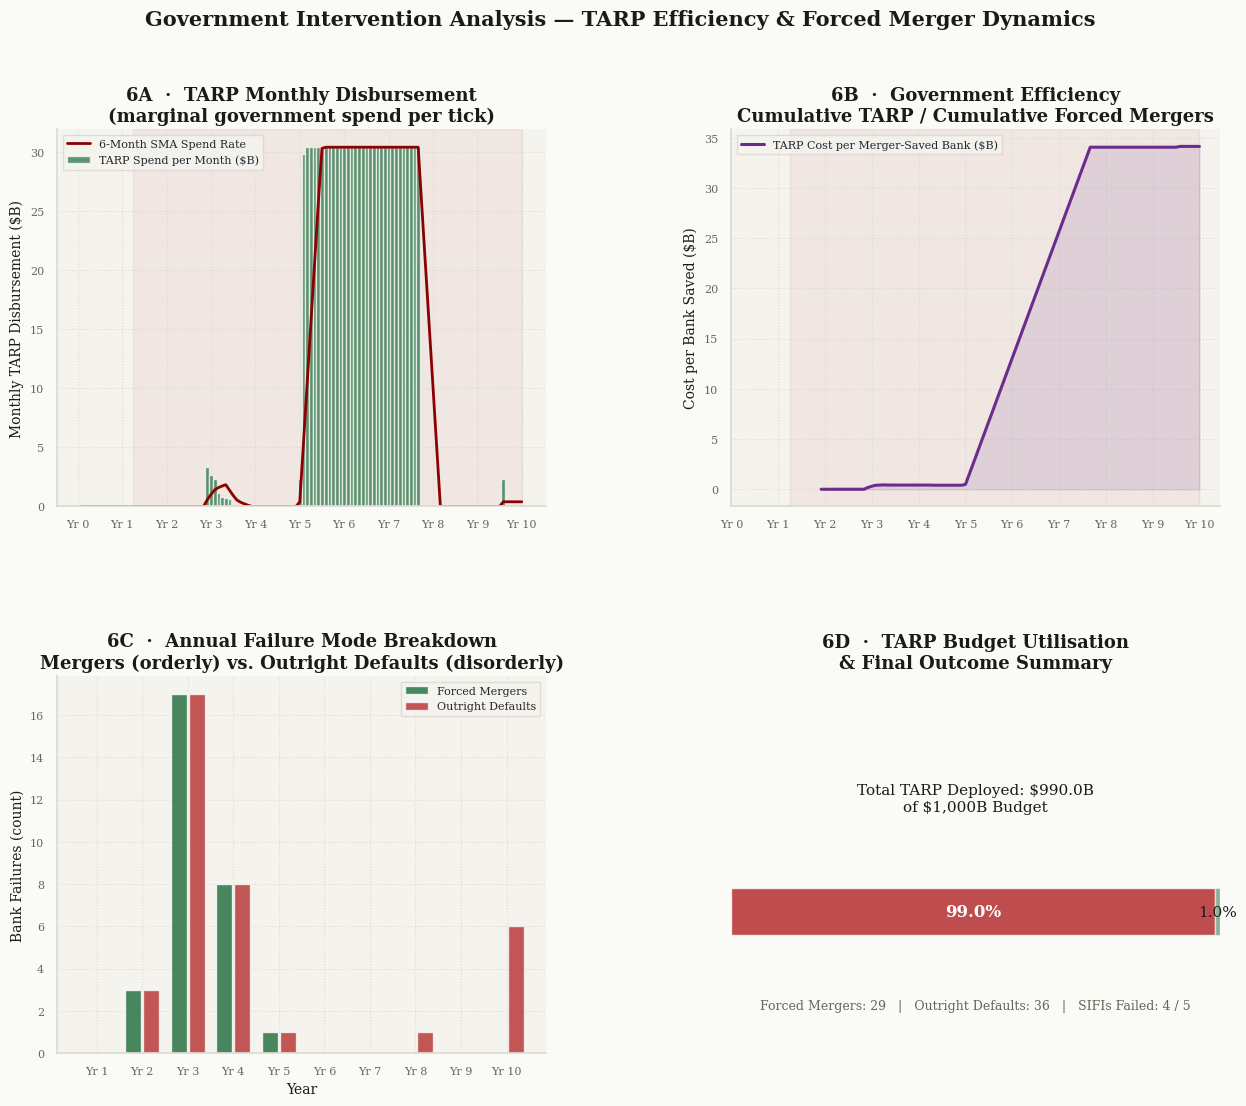

In [ ]:
simulation_results = run_temporal_simulation(
  banks_dict                   = banks,
  network_graph                = sim_G,
  years                        = 10,
  ticks_per_year               = 12,
  ambient_ai_drop              = 0.05,
  general_market_contagion     = 0.02,
  Tw                           = 1.0,
  flare_CUT_up                 = 0.06,
  flare_CUT_low                = 0.02,
  flare_S_l                    = 0.02 / 12,
  flare_S_h                    = 0.10 / 12,
  flare_x                      = 2.0,
  market_depth                 = {"sigma": 0.20, "kappa": 0.05, "ADV_base": 1300.0},
  sifi_recovery_haircut        = 0.80,
  periphery_recovery_haircut   = 0.80,
  confidence_haircut_per_sifi  = 0.02,
  credit_freeze_per_sifi       = 0.02,
  max_credit_freeze            = 0.05,
  max_taxpayer_budget          = 1000.0,
  tarp_trigger                 = 0.85,
  tarp_merger_haircut          = 0.10,
  bailout_threshold            = 0.02,
  vulture_capital_reserves     = 2700.0,
  vulture_activation_threshold = 0.85,
)

plot_all(
    simulation_results,
    vulture_threshold=0.85,
    vulture_reserves=2700.0,
    max_budget=1000.0
)